In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


output_dir = os.path.join('..', 'data', 'processed')
anime_info = pd.read_parquet(os.path.join(output_dir, "anime_clean.parquet"))
train = pd.read_parquet(os.path.join(output_dir, "train_final.parquet"))
test = pd.read_parquet(os.path.join(output_dir, "test_final.parquet"))
val = pd.read_parquet(os.path.join(output_dir, "val_final.parquet"))

# Налаштування стилю для графіків
sns.set_theme(style="whitegrid")

# 1. Завантаження даних
output_dir = os.path.join('..', 'data')
test_m1 = pd.read_parquet(os.path.join(output_dir, "test_complete_m1.parquet"))
test_m2 = pd.read_parquet(os.path.join(output_dir, "test_complete_m2.parquet"))
test_m3 = pd.read_parquet(os.path.join(output_dir, "test_complete_m3.parquet"))

output_dir = os.path.join(output_dir, 'processed')
anime_clean = pd.read_parquet(os.path.join(output_dir, "anime_clean.parquet"))
test_final = pd.read_parquet(os.path.join(output_dir, "test_final.parquet"))

In [2]:
# 2. Розрахунок Baseline (Абсолютна похибка = |Оцінка - Середнє всіх оцінок|)
global_mean = test_final['rating'].mean()
test_final['baseline_abs_error'] = (test_final['rating'] - global_mean).abs()

print(f"Глобальне середнє значення оцінок (Baseline): {global_mean:.4f}")

# 3. Об'єднання всіх похибок в один датафрейм (робимо Merge по user_id та anime_id)
# Припускаємо, що в m1 та m2 похибка називається 'abs_error' (перейменовуємо для уникнення конфліктів)
df_merged = test_final.copy()

df_merged = df_merged.merge(
    test_m1[['user_id', 'anime_id', 'abs_error']].rename(columns={'abs_error': 'm1_abs_error'}), 
    on=['user_id', 'anime_id'], how='left'
)

df_merged = df_merged.merge(
    test_m2[['user_id', 'anime_id', 'abs_error']].rename(columns={'abs_error': 'm2_abs_error'}), 
    on=['user_id', 'anime_id'], how='left'
)

# M3 вже має окремі назви похибок
df_merged = df_merged.merge(
    test_m3[['user_id', 'anime_id', 'svd_abs_error', 'content_abs_error', 'hybrid_abs_error']], 
    on=['user_id', 'anime_id'], how='left'
)

print("Дані успішно об'єднано! Кількість записів:", len(df_merged))

Глобальне середнє значення оцінок (Baseline): 7.5010
Дані успішно об'єднано! Кількість записів: 2735694


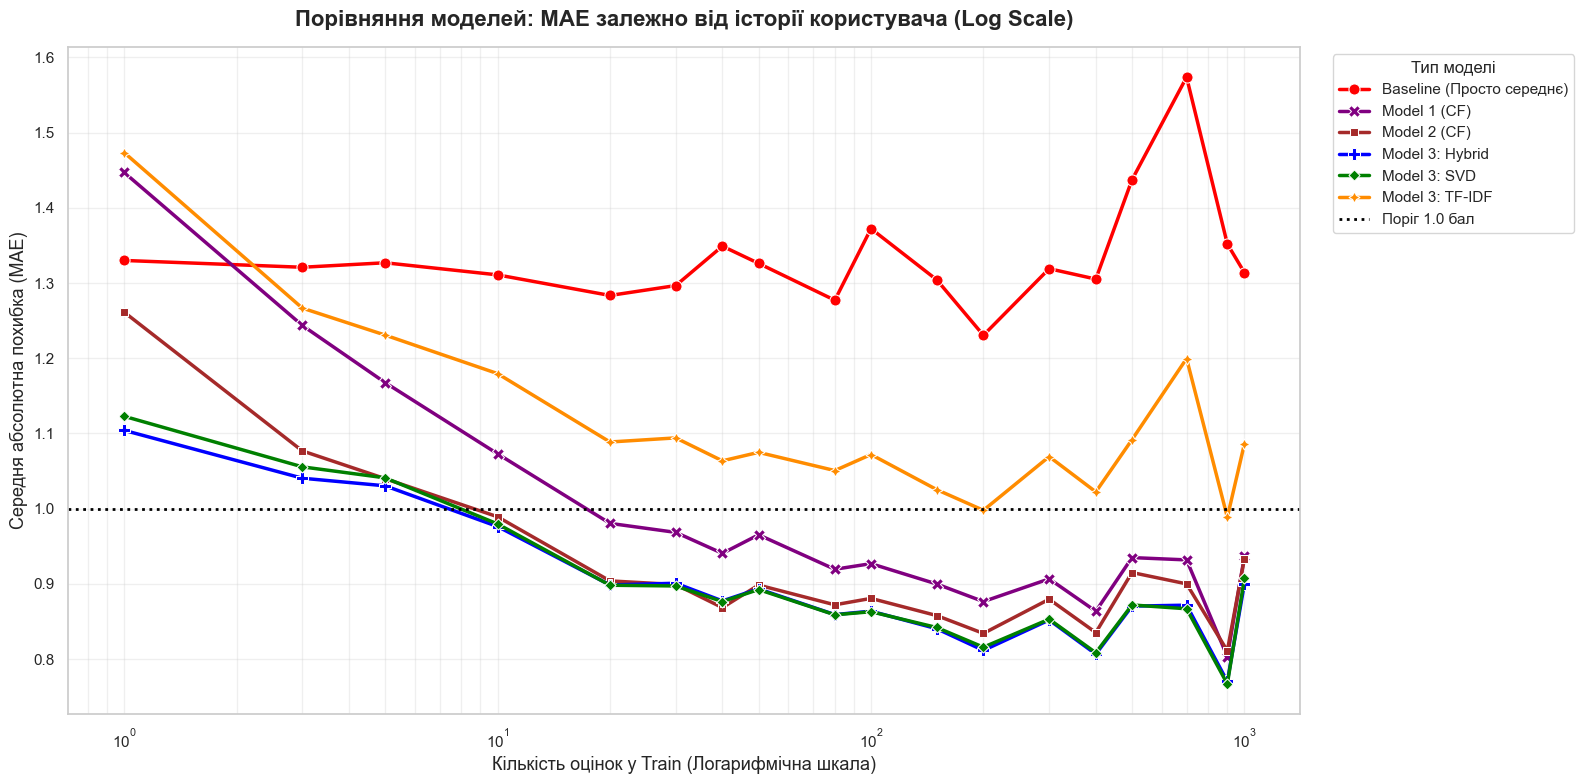

In [3]:
# 1. Задаємо референсні точки (як у попередніх тестах)
ref_counts = [1, 3, 5, 10, 20, 30, 40, 50, 80, 100, 150, 200, 300, 400, 500, 700, 900, 1000]

# Фільтруємо об'єднаний датафрейм
df_ref = df_merged[df_merged['train_count'].isin(ref_counts)].copy()

# 2. Згортаємо дані для графіків
models_dict = {
    'baseline_abs_error': 'Baseline (Просто середнє)',
    'm1_abs_error': 'Model 1 (CF)',
    'm2_abs_error': 'Model 2 (CF)',
    'svd_abs_error': 'Model 3: SVD',
    'content_abs_error': 'Model 3: TF-IDF',
    'hybrid_abs_error': 'Model 3: Hybrid'
}

df_melted_line = df_ref.melt(
    id_vars=['train_count'], 
    value_vars=list(models_dict.keys()), 
    var_name='model_type', 
    value_name='abs_error'
)
df_melted_line['model_type'] = df_melted_line['model_type'].map(models_dict)

# 3. Рахуємо середнє MAE для кожної точки
mean_mae_trends = df_melted_line.groupby(['train_count', 'model_type'])['abs_error'].mean().reset_index()

# 4. Побудова графіка
plt.figure(figsize=(16, 8))

sns.lineplot(
    data=mean_mae_trends, 
    x='train_count', 
    y='abs_error', 
    hue='model_type', 
    style='model_type',    # Різні типи ліній для контрасту
    markers=True,          # Додаємо точки
    dashes=False,          # Суцільні лінії
    linewidth=2.5,
    markersize=8,
    palette=['red', 'purple', 'brown', 'blue', 'green', 'darkorange'] # Кольори
)

plt.xscale('log') # Логарифмічна шкала для X (щоб добре бачити дрібні train_count)
plt.axhline(1.0, color='black', linestyle=':', linewidth=2, label='Поріг 1.0 бал')

plt.title('Порівняння моделей: MAE залежно від історії користувача (Log Scale)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Кількість оцінок у Train (Логарифмічна шкала)', fontsize=13)
plt.ylabel('Середня абсолютна похибка (MAE)', fontsize=13)
plt.legend(title='Тип моделі', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\Anton\AppData\Local\Temp\ipykernel_25080\2001708246.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


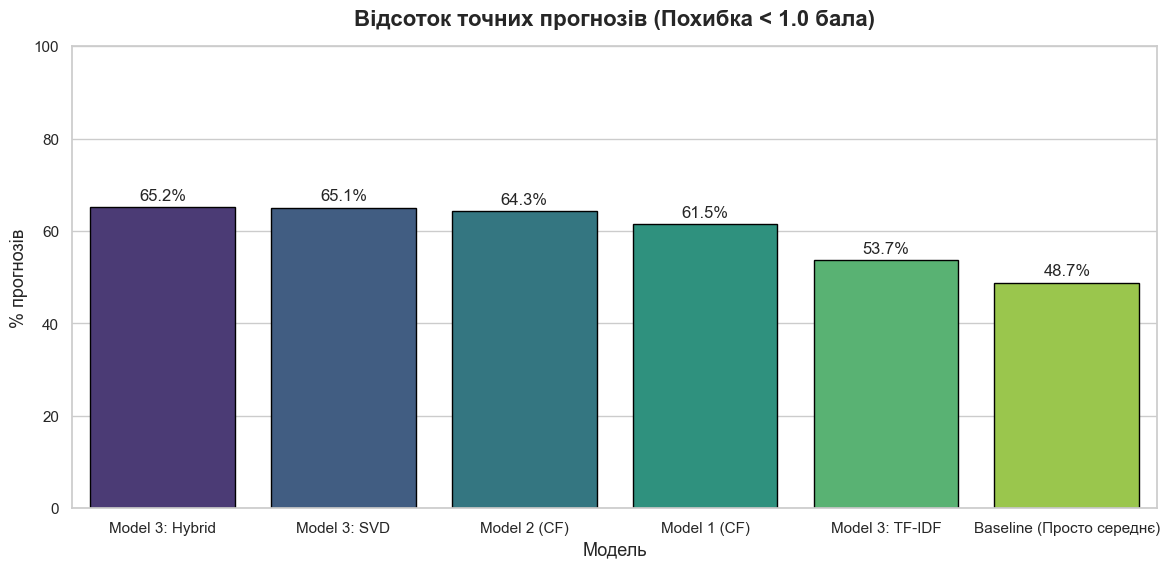

C:\Users\Anton\AppData\Local\Temp\ipykernel_25080\2001708246.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


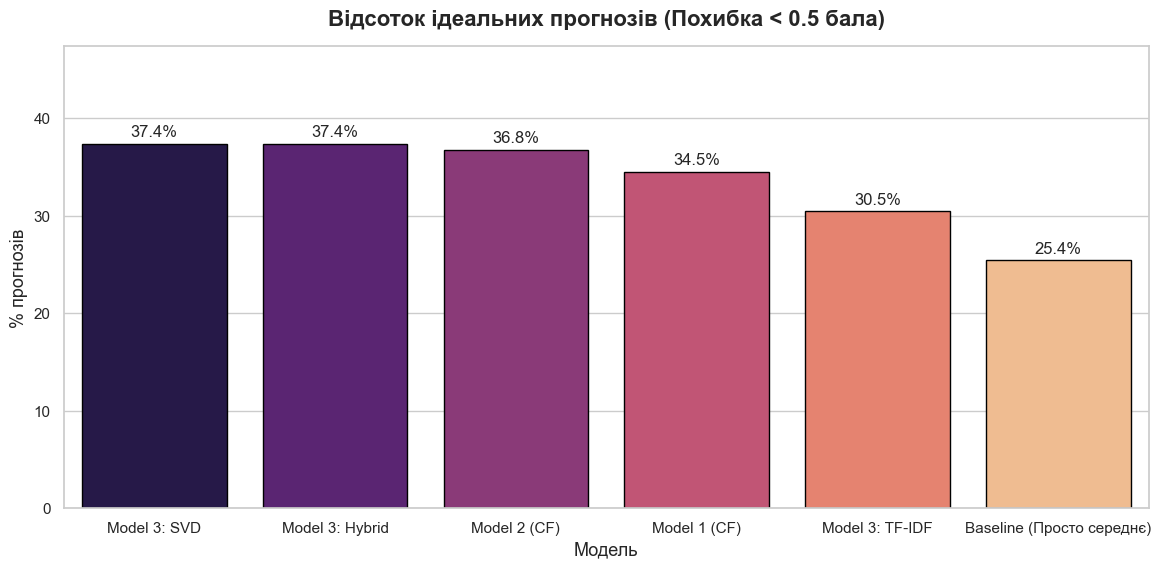

In [4]:
# 1. Розрахунок відсотків успіху для ВСІХ записів (не лише ref_points)
success_rates_1_0 = {}
success_rates_0_5 = {}

for col, name in models_dict.items():
    # Відсоток < 1.0
    pct_1_0 = (df_merged[col] < 1.0).mean() * 100
    success_rates_1_0[name] = pct_1_0
    
    # Відсоток < 0.5
    pct_0_5 = (df_merged[col] < 0.5).mean() * 100
    success_rates_0_5[name] = pct_0_5

# Перетворюємо у DataFrame для зручного плоттінгу
df_success = pd.DataFrame({
    'Model': list(success_rates_1_0.keys()),
    'Error < 1.0 (%)': list(success_rates_1_0.values()),
    'Error < 0.5 (%)': list(success_rates_0_5.values())
})

# --- Побудова Графіка 2: Похибка < 1.0 ---
plt.figure(figsize=(14, 6))
ax1 = sns.barplot(
    data=df_success.sort_values('Error < 1.0 (%)', ascending=False), # Сортуємо від кращої до гіршої
    x='Model', 
    y='Error < 1.0 (%)', 
    palette='viridis',
    edgecolor='black'
)

# Додаємо цифри над стовпчиками
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', padding=3, fontsize=12)

plt.title('Відсоток точних прогнозів (Похибка < 1.0 бала)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Модель', fontsize=13)
plt.ylabel('% прогнозів', fontsize=13)
plt.ylim(0, 100)
plt.show()


# --- Побудова Графіка 3: Похибка < 0.5 ---
plt.figure(figsize=(14, 6))
ax2 = sns.barplot(
    data=df_success.sort_values('Error < 0.5 (%)', ascending=False), 
    x='Model', 
    y='Error < 0.5 (%)', 
    palette='magma', # Інша палітра для розмежування
    edgecolor='black'
)

# Додаємо цифри над стовпчиками
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', padding=3, fontsize=12)

plt.title('Відсоток ідеальних прогнозів (Похибка < 0.5 бала)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Модель', fontsize=13)
plt.ylabel('% прогнозів', fontsize=13)
plt.ylim(0, max(df_success['Error < 0.5 (%)']) + 10) # Трохи динамічніша вісь Y, бо відсотки будуть менші
plt.show()

In [5]:
# Розраховуємо середнє значення для колонок з абсолютними похибками
mae_results = df_merged[[
    'baseline_abs_error', 
    'm1_abs_error', 
    'm2_abs_error', 
    'svd_abs_error', 
    'content_abs_error', 
    'hybrid_abs_error'
]].mean().sort_values()

# Виводимо результати від найкращого (найменшого) до найгіршого
print("--- Загальне MAE для кожної моделі ---")
print(mae_results.round(4))

--- Загальне MAE для кожної моделі ---
hybrid_abs_error      0.9018
svd_abs_error         0.9042
m2_abs_error          0.9276
m1_abs_error          0.9891
content_abs_error     1.1056
baseline_abs_error    1.3330
dtype: float64


In [6]:
import pickle
import tensorflow as tf
from tqdm.notebook import tqdm

sns.set_theme(style="whitegrid")


# Отримуємо список всіх унікальних аніме
all_unique_animes = train['anime_id'].unique()
print(f"Загальна кількість унікальних аніме для ранжування: {len(all_unique_animes)}")

# 2. Створюємо Базові моделі (Baselines)
# Baseline 1: Просто найпопулярніші (за кількістю будь-яких оцінок)
pop_b1 = train.groupby('anime_id').size().reset_index(name='count_all')
top_10_b1 = pop_b1.sort_values('count_all', ascending=False).head(10)['anime_id'].tolist()

# Baseline 2: Найпопулярніші серед "хороших" (оцінка >= 8)
pop_b2 = train[train['rating'] >= 8].groupby('anime_id').size().reset_index(name='count_good')
top_10_b2 = pop_b2.sort_values('count_good', ascending=False).head(10)['anime_id'].tolist()

# Порівнюємо їх
print("\n--- Перевірка Базових Моделей ---")
overlap = set(top_10_b1).intersection(set(top_10_b2))
print(f"Збіг у Топ-10 між двома бейзлайнами: {len(overlap)} з 10")
if len(overlap) == 10:
    print("Висновок: Це фактично один і той самий топ. Найпопулярніші аніме отримують найбільше вісімок просто через масовість.")
else:
    print("Висновок: Топи відрізняються, якість (>=8) має власну вагу.")

Загальна кількість унікальних аніме для ранжування: 15529

--- Перевірка Базових Моделей ---
Збіг у Топ-10 між двома бейзлайнами: 6 з 10
Висновок: Топи відрізняються, якість (>=8) має власну вагу.


In [10]:
from sklearn.preprocessing import LabelEncoder

# 2. Енкодування юзерів (зі всіх трьох вибірок)
user_enc = LabelEncoder()
all_users = pd.concat([train['user_id'], val['user_id'], test['user_id']])
user_enc.fit(all_users)

# Енкодування аніме (зі всіх трьох вибірок, без anime_clean)
anime_enc = LabelEncoder()
all_anime = pd.concat([train['anime_id'], val['anime_id'], test['anime_id']])
anime_enc.fit(all_anime)

# 3. Трансформація ідентифікаторів
def transform_ids(df):
    df = df.copy()
    df['user_encoded'] = user_enc.transform(df['user_id'])
    df['anime_encoded'] = anime_enc.transform(df['anime_id'])
    return df

train = transform_ids(train)
val = transform_ids(val)
test = transform_ids(test)

# 4. Отримання необхідних масивів для прогнозів
# Енкодовані юзери з test та енкодовані аніме з train
test_users_encoded = test['user_encoded'].unique()
train_anime_encoded = train['anime_encoded'].unique()

# Виводимо розмірності для перевірки
print(f"Кількість унікальних енкодованих юзерів у test: {len(test_users_encoded)}")
print(f"Кількість унікальних енкодованих аніме у train: {len(train_anime_encoded)}")

Кількість унікальних енкодованих юзерів у test: 28047
Кількість унікальних енкодованих аніме у train: 15529


In [11]:
# Створюємо словник мапінгу: {оригінальний_MAL_id: енкодований_id}
anime_mapping = dict(zip(anime_enc.classes_, range(len(anime_enc.classes_))))

print(f"Словник готовий! Всього аніме у словнику: {len(anime_mapping)}")

# Якщо захочете перевірити перші 5 записів:
print(list(anime_mapping.items())[:5])

Словник готовий! Всього аніме у словнику: 15529
[(np.uint16(1), 0), (np.uint16(5), 1), (np.uint16(6), 2), (np.uint16(7), 3), (np.uint16(8), 4)]


In [12]:
# Беремо 5 випадкових рядків для перевірки
check_sample = train.sample(5, random_state=42)

print("Перевірка мапінгу:")
for _, row in check_sample.iterrows():
    orig_id = row['anime_id']
    df_encoded = row['anime_encoded']
    
    # Шукаємо цей же ID у нашому словнику
    dict_encoded = anime_mapping[orig_id]
    
    # Порівнюємо
    is_match = (df_encoded == dict_encoded)
    print(f"MAL ID: {orig_id:<6} | В таблиці: {df_encoded:<5} | У словнику: {dict_encoded:<5} | Збіг: {is_match}")

Перевірка мапінгу:
MAL ID: 13759  | В таблиці: 6955  | У словнику: 6955  | Збіг: True
MAL ID: 9441   | В таблиці: 5731  | У словнику: 5731  | Збіг: True
MAL ID: 31580  | В таблиці: 10470 | У словнику: 10470 | Збіг: True
MAL ID: 34821  | В таблиці: 11904 | У словнику: 11904 | Збіг: True
MAL ID: 39292  | В таблиці: 14237 | У словнику: 14237 | Збіг: True


In [14]:
output_dir = os.path.join('..', 'data')

In [15]:
# 3. Завантаження Keras моделей
model_v1 = tf.keras.models.load_model(os.path.join(output_dir, 'anime_model_v1.keras'))
model_v2 = tf.keras.models.load_model(os.path.join(output_dir, 'anime_model_v2.keras'))

In [9]:

# Вкажіть вашу папку, де лежать файли
data_dir = os.path.join('..', 'data')

# 2. Завантаження даних контентної моделі
content_filepath = os.path.join(data_dir, 'content_model_data.pkl')
with open(content_filepath, 'rb') as f:
    content_data = pickle.load(f)

# Відразу "розпаковуємо" словник у зручні змінні
cosine_sim = content_data['cosine_sim']
indices = content_data['indices']
valid_anime_ids = content_data['valid_anime_ids']
user_ratings_train = content_data['user_ratings_train']
global_mean = content_data['global_mean']
print("✅ Дані контентної моделі завантажені.")

# 3. Завантаження ваг для гібридної моделі
weights_filepath = os.path.join(data_dir, 'hybrid_weights.pkl')
with open(weights_filepath, 'rb') as f:
    hybrid_weights = pickle.load(f)

w_collab = hybrid_weights['w_collab']
w_content = hybrid_weights['w_content']
print("✅ Гібридні ваги завантажені.")

✅ Дані контентної моделі завантажені.
✅ Гібридні ваги завантажені.


In [17]:
ref_counts = [1, 3, 5, 10, 20, 30, 40, 50, 80, 100, 150, 200, 300, 400, 500, 700, 900, 1000]
count_col = 'train_count'

# 1. Отримуємо унікальних користувачів та їх кількість оцінок
user_stats = test[['user_id', count_col]].drop_duplicates()

sampled_users_list = []

# 2. Відбираємо по 100 рандомних юзерів для кожної референсної точки
for count in ref_counts:
    users_in_group = user_stats[user_stats[count_col] == count]
    
    # Беремо 100, або всіх доступних, якщо їх менше 100
    sample_size = min(100, len(users_in_group))
    
    if sample_size > 0:
        sampled = users_in_group.sample(n=sample_size, random_state=42)
        sampled_users_list.extend(sampled['user_id'].tolist())

# 3. Створюємо відфільтрований датасет тільки для відібраних користувачів
test_sampled = test[test['user_id'].isin(sampled_users_list)].copy()

print(f"Відібрано унікальних користувачів: {len(sampled_users_list)}")
print(f"Загальна кількість рядків у test_sampled: {len(test_sampled)}")

Відібрано унікальних користувачів: 1590
Загальна кількість рядків у test_sampled: 311617


In [24]:
# 1. Зберігаємо датасет з відібраними користувачами
test_sampled_path = os.path.join(output_dir, 'test_sampled.parquet')
test_sampled.to_parquet(test_sampled_path)
print(f"✅ Збережено: {test_sampled_path}")

# 2. зберігаємо список усіх унікальних аніме (MAL_ID)

unique_animes_path = os.path.join(output_dir, 'all_unique_animes.pkl')
with open(unique_animes_path, 'wb') as f:
    pickle.dump(all_unique_animes, f)
print(f"✅ Збережено: {unique_animes_path} (Кількість: {len(all_unique_animes)})")

✅ Збережено: ..\data\test_sampled.parquet
✅ Збережено: ..\data\all_unique_animes.pkl (Кількість: 15529)


In [19]:
# Аналіз унікальних користувачів у кожній групі train_count
print("Кількість унікальних користувачів у кожній групі train_count:")

user_distribution = test_sampled.groupby('train_count')['user_id'].nunique().reset_index()
user_distribution.columns = ['train_count', 'unique_users']

print(user_distribution.to_string(index=False))

print(f"\nВсього унікальних користувачів: {test_sampled['user_id'].nunique()}")
print(f"Всього рядків у test_sampled: {len(test_sampled)}")

Кількість унікальних користувачів у кожній групі train_count:
 train_count  unique_users
         1.0           100
         3.0           100
         5.0           100
        10.0           100
        20.0           100
        30.0           100
        40.0           100
        50.0           100
        80.0           100
       100.0           100
       150.0           100
       200.0           100
       300.0           100
       400.0           100
       500.0            60
       700.0            60
       900.0            60
      1000.0            10

Всього унікальних користувачів: 1590
Всього рядків у test_sampled: 311617


In [25]:
# 1. Готуємо словник історії для маскування (хто що дивився у train)
user_history_train = train.groupby('user_id')['anime_id'].apply(list).to_dict()

# 2. Готуємо масиви оцінок для Baseline на основі ваших pop_b1 та pop_b2
b1_dict = dict(zip(pop_b1['anime_id'], pop_b1['count_all']))
b2_dict = dict(zip(pop_b2['anime_id'], pop_b2['count_good']))

preds_b1_global = np.array([b1_dict.get(aid, 0) for aid in all_unique_animes], dtype=np.float32)
preds_b2_global = np.array([b2_dict.get(aid, 0) for aid in all_unique_animes], dtype=np.float32)

# 3. Готуємо масив енкодованих аніме для моделей Keras (швидкий доступ)
all_animes_encoded = np.array([anime_mapping[aid] for aid in all_unique_animes])

In [26]:
from sklearn.metrics import roc_auc_score

# Функція ранжування
def calculate_ranking_metrics(true_items_ratings, predicted_ranked_items, k=10):
    relevant_items = {iid for iid, rating in true_items_ratings.items() if rating >= 8}
    if not relevant_items: return None 
        
    top_k_pred = predicted_ranked_items[:k]
    hits = len(set(top_k_pred).intersection(relevant_items))
    
    precision = hits / k
    recall = hits / len(relevant_items)
    
    mrr = 0.0
    for rank, item in enumerate(predicted_ranked_items):
        if item in relevant_items:
            mrr = 1.0 / (rank + 1)
            break
            
    y_true = [1 if item in relevant_items else 0 for item in predicted_ranked_items]
    y_scores = list(range(len(predicted_ranked_items), 0, -1)) 
    try: auc = roc_auc_score(y_true, y_scores)
    except: auc = np.nan
        
    return {
        'Precision@10': precision, 
        'Recall@10': recall, 
        'MRR': mrr, 
        'AUC': auc,
        'Top10_Items': top_k_pred
    }

In [31]:
from tqdm import tqdm

# ==========================================
# 5. ГОЛОВНИЙ ЦИКЛ ОЦІНЮВАННЯ
# ==========================================
new_results_list = []
unique_users = test_sampled['user_id'].unique()

print(f"Запуск генерації для {len(unique_users)} користувачів...")

for user_id in tqdm(unique_users, desc="Оцінювання Keras та Baselines"):
    
    user_test_data = test_sampled[test_sampled['user_id'] == user_id]
    true_ratings = dict(zip(user_test_data['anime_id'], user_test_data['rating']))
    
    # Пропускаємо, якщо немає оцінок >= 8
    if not any(r >= 8 for r in true_ratings.values()):
        continue
    
    train_count = user_test_data['train_count'].iloc[0]
    
    # --- Прогнози Keras ---
    u_enc = user_test_data['user_encoded'].iloc[0]
    user_enc_array = np.full(len(all_unique_animes), u_enc)
    
    preds_v1 = model_v1.predict([user_enc_array, all_animes_encoded], batch_size=20000, verbose=0).flatten()
    preds_v2 = model_v2.predict([user_enc_array, all_animes_encoded], batch_size=20000, verbose=0).flatten()
    
    # --- Прогнози Baselines ---
    preds_b1 = preds_b1_global.copy()
    preds_b2 = preds_b2_global.copy()
    
    # --- Маскування історії ---
    history_aids = user_history_train.get(user_id, [])
    seen_mask = np.isin(all_unique_animes, history_aids)
    
    preds_v1[seen_mask] = -np.inf
    preds_v2[seen_mask] = -np.inf
    preds_b1[seen_mask] = -np.inf
    preds_b2[seen_mask] = -np.inf
    
    # --- Сортування та підрахунок ---
    models_preds = {
        'Model_v1': preds_v1,
        'Model_v2': preds_v2,
        'Baseline_1': preds_b1,
        'Baseline_2': preds_b2
    }
    
    user_metrics = {'user_id': user_id, 'train_count': train_count}
    
    for model_name, predictions in models_preds.items():
        top_indices = np.argsort(predictions)[::-1]
        ranked_items = all_unique_animes[top_indices].tolist()
        
        metrics = calculate_ranking_metrics(true_ratings, ranked_items, k=10)
        
        if metrics:
            for m_name, m_val in metrics.items():
                user_metrics[f'{model_name}_{m_name}'] = m_val
                
    new_results_list.append(user_metrics)

Запуск генерації для 1590 користувачів...


Оцінювання Keras та Baselines: 100%|██████████| 1590/1590 [05:11<00:00,  5.10it/s]


In [32]:
# 6. Збереження результатів
keras_metrics_df = pd.DataFrame(new_results_list)
output_filename = os.path.join(output_dir, 'keras_baselines_metrics.parquet')
keras_metrics_df.to_parquet(output_filename)

print(f"\n✅ Готово! Результати нових моделей збережено у: {output_filename}")
print(keras_metrics_df.head(3))


✅ Готово! Результати нових моделей збережено у: ..\data\keras_baselines_metrics.parquet
   user_id  train_count  Model_v1_Precision@10  Model_v1_Recall@10  \
0      371        900.0                    0.0            0.000000   
1      716         50.0                    0.1            0.010000   
2      871         80.0                    0.6            0.027027   

   Model_v1_MRR  Model_v1_AUC  \
0      0.013514      0.950757   
1      0.200000      0.856107   
2      1.000000      0.874964   

                                Model_v1_Top10_Items  Model_v2_Precision@10  \
0  [820, 28977, 21939, 457, 24701, 37491, 39486, ...                    0.0   
1  [28977, 9969, 918, 15417, 5114, 35180, 24701, ...                    0.2   
2  [9253, 4181, 5114, 32281, 35180, 28851, 38524,...                    0.2   

   Model_v2_Recall@10  Model_v2_MRR  ...  Baseline_1_Precision@10  \
0            0.000000      0.016949  ...                      0.0   
1            0.020000      0.250000  ...  

In [ ]:
output_dir = os.path.join('..', 'data')
all_models_ranking_metrics = pd.read_parquet(os.path.join(output_dir, "all_models_ranking_metrics.parquet"))

In [40]:
all_models_ranking_metrics = pd.merge(all_models_ranking_metrics, keras_metrics_df, on=['user_id', 'train_count'], how='inner')
all_models_ranking_metrics.info()

<class 'pandas.DataFrame'>
RangeIndex: 1587 entries, 0 to 1586
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  1587 non-null   int32  
 1   train_count              1587 non-null   float64
 2   SVD_Precision@10         1587 non-null   float64
 3   SVD_Recall@10            1587 non-null   float64
 4   SVD_MRR                  1587 non-null   float64
 5   SVD_AUC                  1587 non-null   float64
 6   SVD_Top10_Items          1587 non-null   object 
 7   Content_Precision@10     1587 non-null   float64
 8   Content_Recall@10        1587 non-null   float64
 9   Content_MRR              1587 non-null   float64
 10  Content_AUC              1587 non-null   float64
 11  Content_Top10_Items      1587 non-null   object 
 12  Hybrid_Precision@10      1587 non-null   float64
 13  Hybrid_Recall@10         1587 non-null   float64
 14  Hybrid_MRR               1587 non-n

In [41]:
# Припустимо, metrics_df - це датафрейм з розрахованими метриками
# Точні назви моделей (як вони записані у скриптах)
models_list = ['SVD', 'Content', 'Hybrid', 'Model_v1', 'Model_v2', 'Baseline_1', 'Baseline_2']

# Назви метрик залишилися незмінними
metrics_list = ['Precision@10', 'Recall@10', 'MRR', 'AUC']

summary_data = []

for model in models_list:
    row = {'Model': model}
    for metric in metrics_list:
        col_name = f"{model}_{metric}"
        row[metric] = all_models_ranking_metrics[col_name].mean() # Середнє по всім користувачам
    
    # Розрахунок Coverage (Покриття)
    # Це відсоток унікальних аніме, які модель хоча б раз порекомендувала у Топ-10
    all_recommended_items = set()
    for items_list in all_models_ranking_metrics[f"{model}_Top10_Items"]:
        all_recommended_items.update(items_list)
    
    row['Coverage (%)'] = (len(all_recommended_items) / len(all_unique_animes)) * 100
    
    summary_data.append(row)

summary_table = pd.DataFrame(summary_data).set_index('Model')
print("\n=== ЗВЕДЕНА ТАБЛИЦЯ МЕТРИК РАНЖУВАННЯ ===")
display(summary_table.round(4))


=== ЗВЕДЕНА ТАБЛИЦЯ МЕТРИК РАНЖУВАННЯ ===


,Precision@10,Recall@10,MRR,AUC,Coverage (%)
Model,,,,,
SVD,0.1849,0.0289,0.3657,0.8769,7.2509
Content,0.0004,0.0000,0.0017,0.4986,9.4018
Hybrid,0.1961,0.0318,0.3870,0.8780,7.6695
Model_v1,0.1282,0.0197,0.2765,0.8076,21.4116
Model_v2,0.1428,0.0219,0.2795,0.8864,3.1296
Baseline_1,0.3323,0.0613,0.5784,0.9539,0.6246
Baseline_2,0.3515,0.0654,0.5882,0.9568,0.5924


C:\Users\Anton\AppData\Local\Temp\ipykernel_25080\647893504.py:34: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


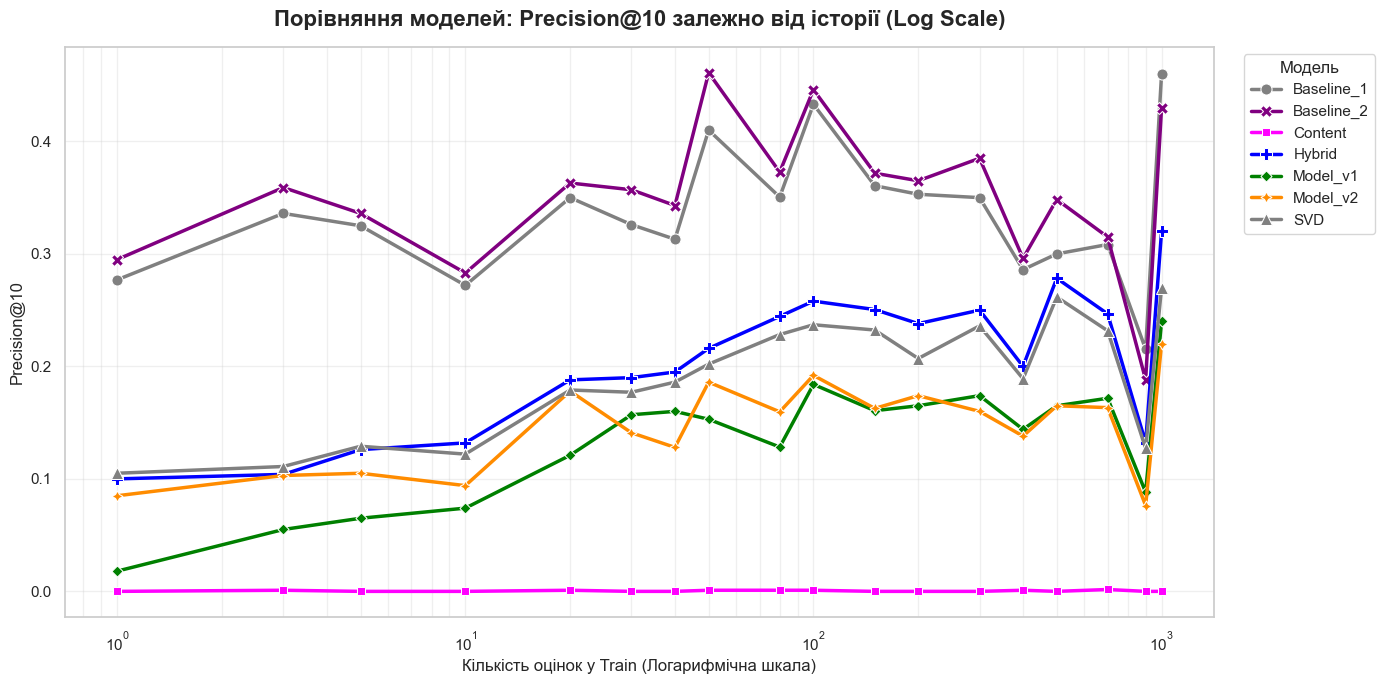

C:\Users\Anton\AppData\Local\Temp\ipykernel_25080\647893504.py:34: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


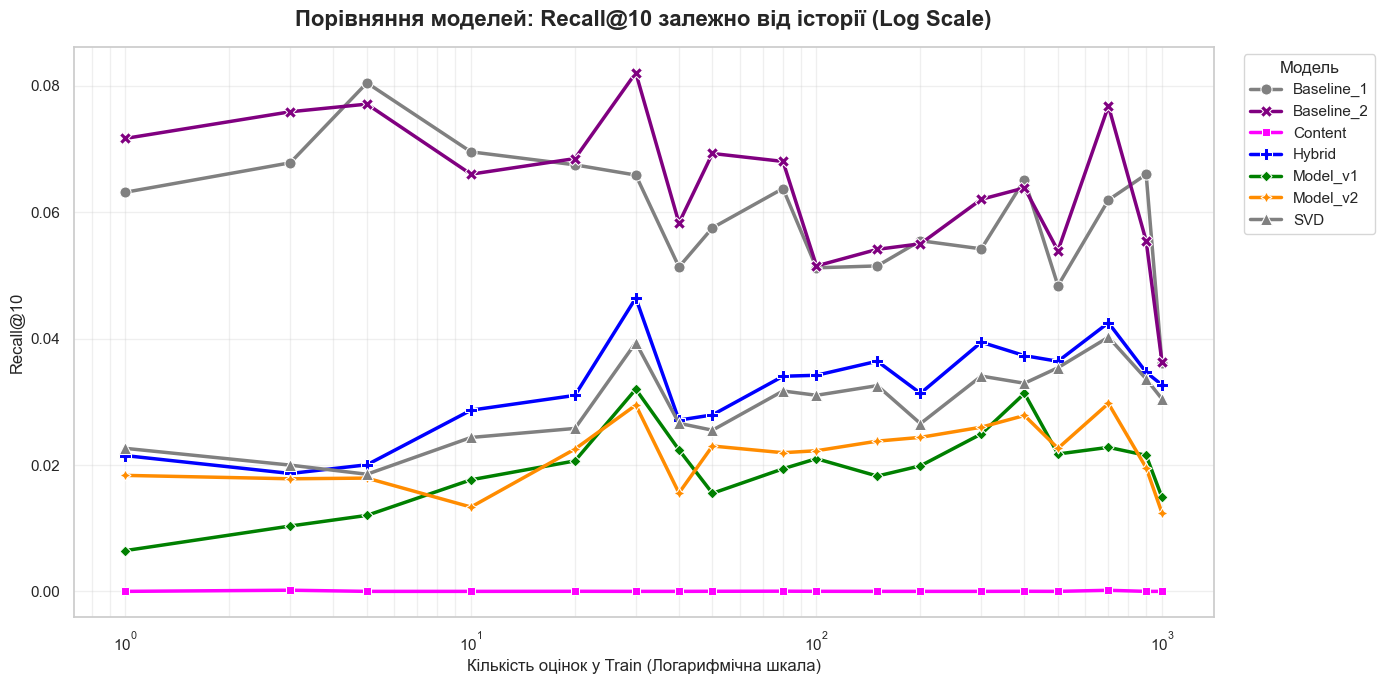

C:\Users\Anton\AppData\Local\Temp\ipykernel_25080\647893504.py:34: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


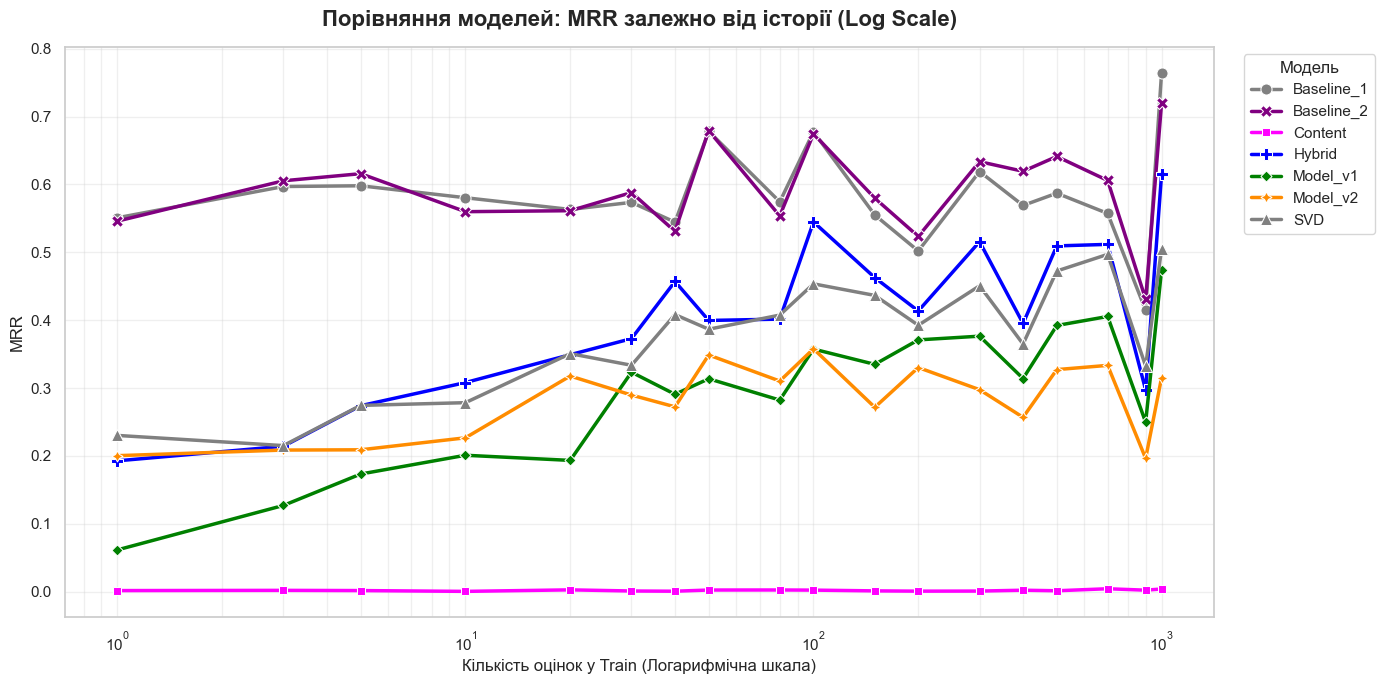

C:\Users\Anton\AppData\Local\Temp\ipykernel_25080\647893504.py:34: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


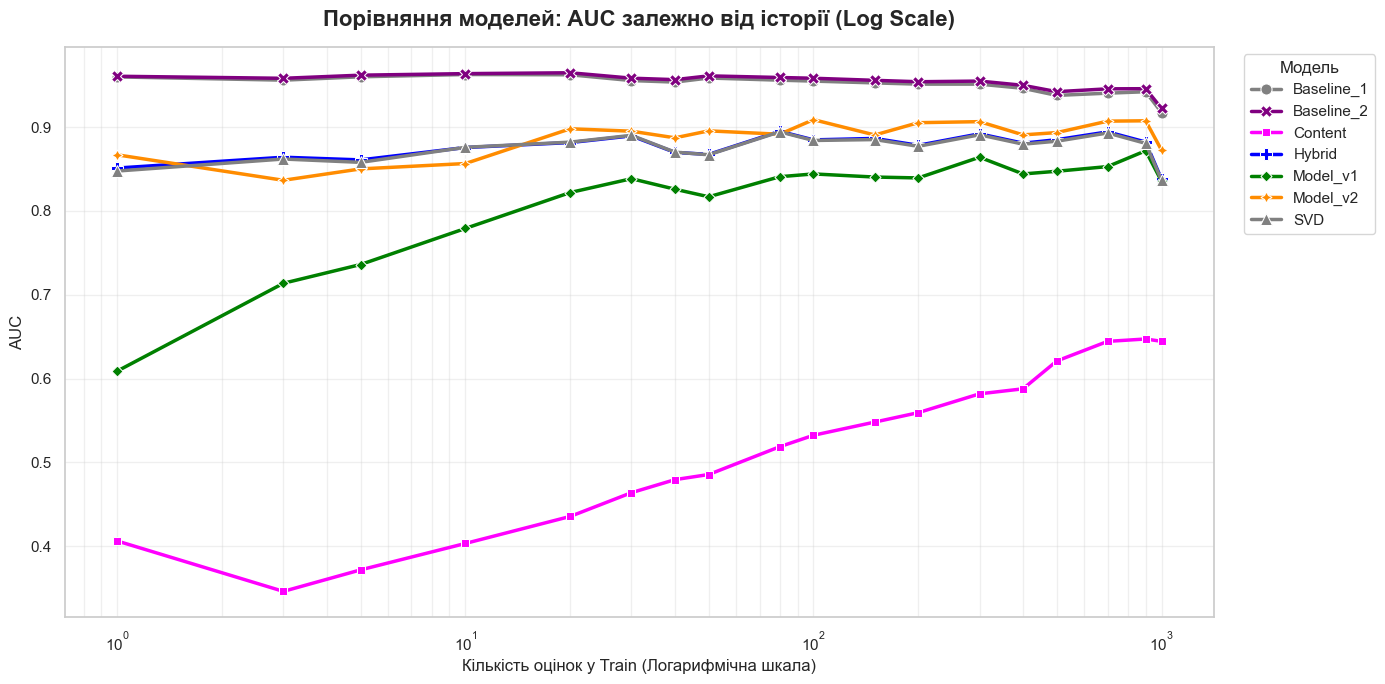

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Підготовка даних: злиття all_models_ranking_metrics з кількістю оцінок в train
# Припускаємо, що в all_models_ranking_metrics є колонка 'train_count'
ref_counts = [1, 3, 5, 10, 20, 30, 40, 50, 80, 100, 150, 200, 300, 400, 500, 700, 900, 1000]
df_plot = all_models_ranking_metrics[all_models_ranking_metrics['train_count'].isin(ref_counts)].copy()

metrics_to_plot = ['Precision@10', 'Recall@10', 'MRR', 'AUC']
colors = ['grey', 'purple', 'magenta', 'blue', 'green', 'darkorange'] # Кольори для 6 моделей

# Запускаємо цикл: кожна ітерація - це новий, окремий графік
for metric in metrics_to_plot:
    # Створюємо нове, повністю незалежне полотно
    plt.figure(figsize=(14, 7))
    
    # Збираємо дані для однієї метрики з усіх моделей
    cols_to_melt = [f"{model}_{metric}" for model in models_list]
    
    df_metric_melted = df_plot.melt(
        id_vars=['train_count'],
        value_vars=cols_to_melt,
        var_name='Model',
        value_name='Value'
    )
    
    # Очищуємо назви моделей для легенди (видаляємо суфікс метрики, наприклад "_Precision@10")
    df_metric_melted['Model'] = df_metric_melted['Model'].str.replace(f'_{metric}', '')
    
    # Рахуємо середнє значення для кожної референсної точки
    trend_data = df_metric_melted.groupby(['train_count', 'Model'])['Value'].mean().reset_index()
    
    # Побудова графіка
    sns.lineplot(
        data=trend_data, 
        x='train_count', 
        y='Value', 
        hue='Model', 
        style='Model', 
        markers=True, 
        dashes=False, 
        linewidth=2.5,
        palette=colors,
        markersize=8
    )
    
    # Налаштування осей та краси
    plt.xscale('log')
    plt.title(f'Порівняння моделей: {metric} залежно від історії (Log Scale)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Кількість оцінок у Train (Логарифмічна шкала)', fontsize=12)
    plt.ylabel(metric, fontsize=12)
    
    # Виносимо легенду за межі графіка, щоб вона не перекривала лінії
    plt.legend(title='Модель', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
    plt.grid(True, which="both", alpha=0.3)
    
    plt.tight_layout()
    
    # Виводимо графік на екран (це розділяє їх у Jupyter Notebook)
    plt.show()
    
    # Додаємо візуальний роздільник між виводами
    print("\n" + "="*80 + "\n")

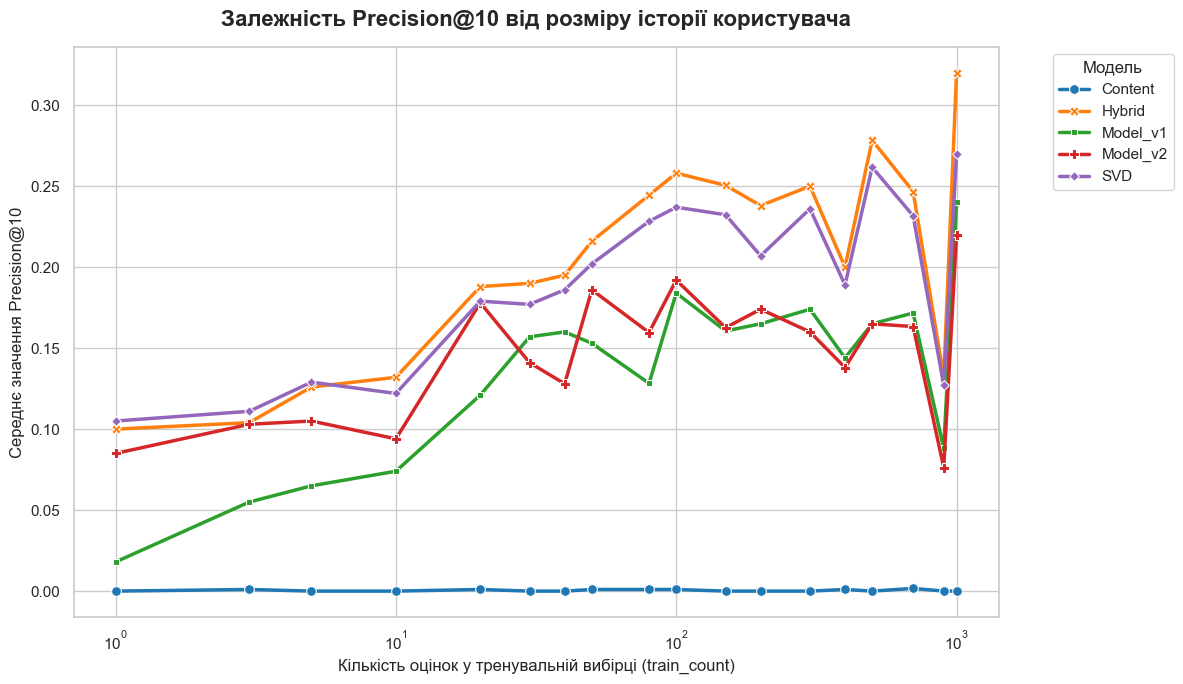

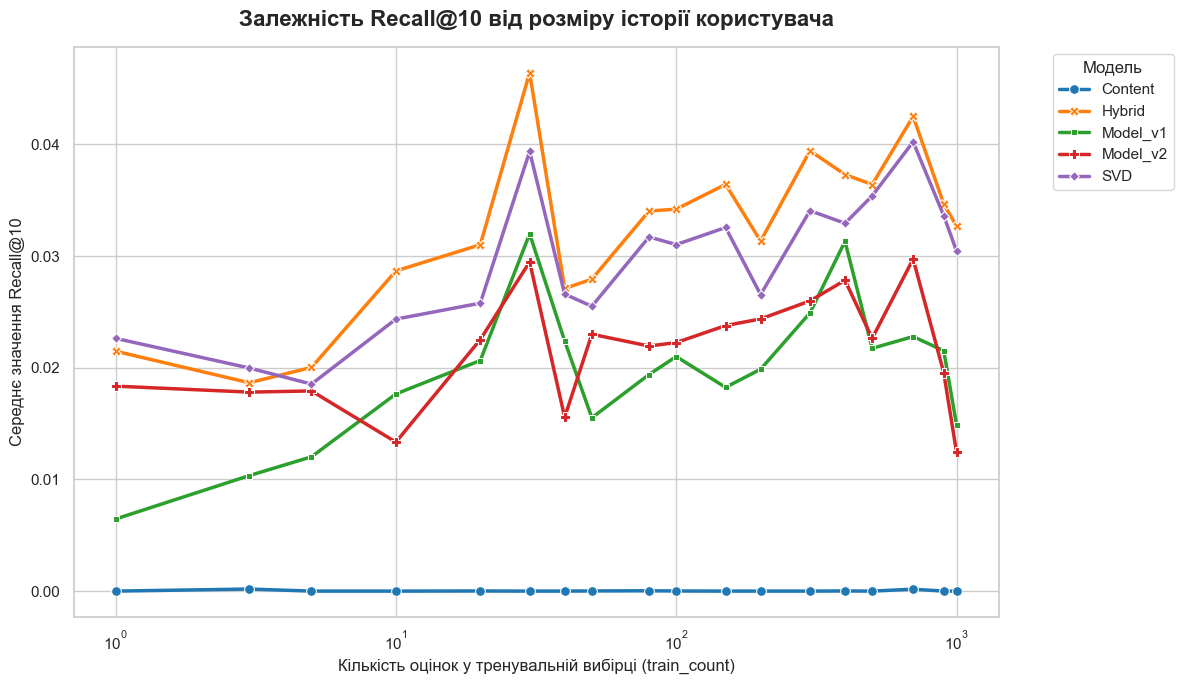

Exception ignored in: <function tqdm.__del__ at 0x000001DC89B6ACA0>
Traceback (most recent call last):
  File "c:\Users\Anton\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\Anton\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x000001DC89B6ACA0>
Traceback (most recent call last):
  File "c:\Users\Anton\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\Anton\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


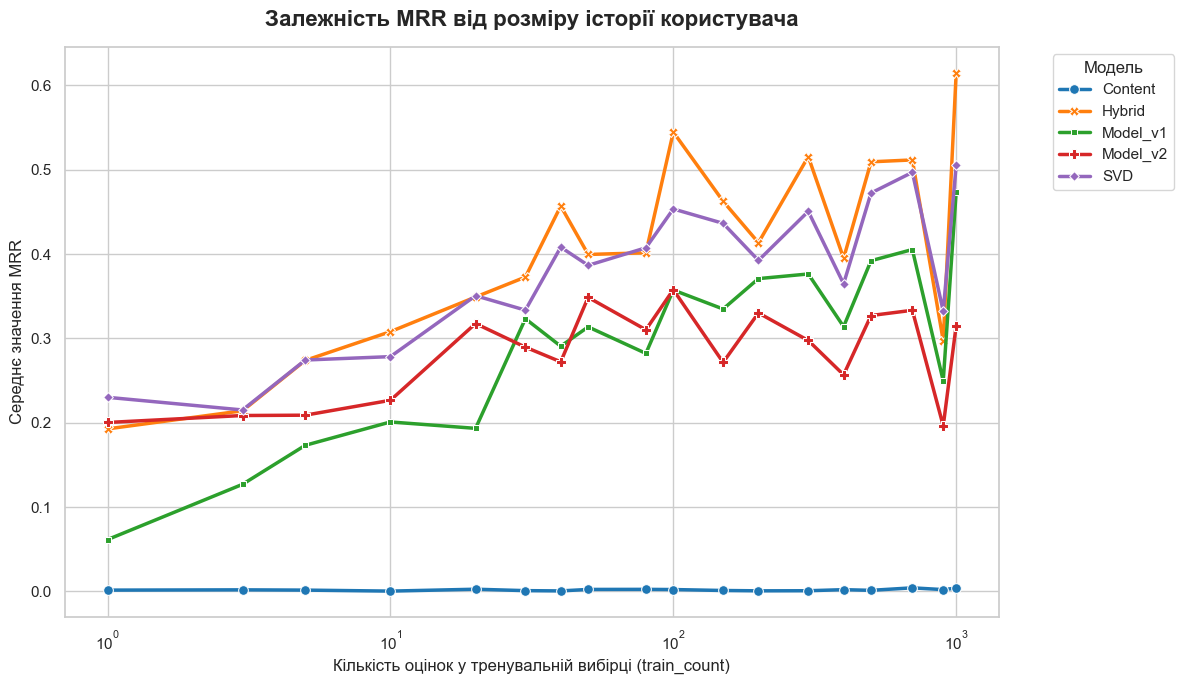

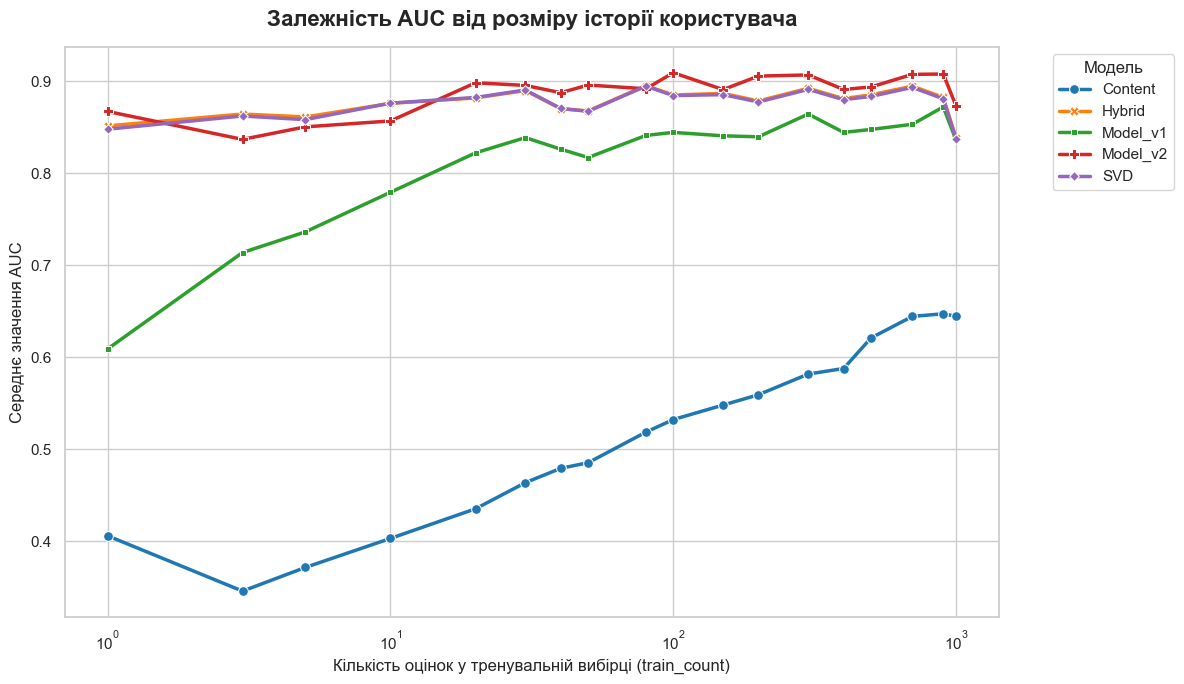

In [45]:
# Налаштування стилю
sns.set_theme(style="whitegrid")


# 2. Наші правильні списки
models_list = ['SVD', 'Content', 'Hybrid', 'Model_v1', 'Model_v2']
metrics_to_plot = ['Precision@10', 'Recall@10', 'MRR', 'AUC']

# 3. Побудова графіків
for metric in metrics_to_plot:
    plt.figure(figsize=(12, 7))
    
    # Збираємо назви колонок для поточної метрики (напр., 'SVD_AUC', 'Model_v1_AUC' тощо)
    cols_to_melt = [f"{model}_{metric}" for model in models_list]
    
    # Виділяємо потрібні дані та згортаємо їх
    df_plot = all_models_ranking_metrics[['train_count'] + cols_to_melt].copy()
    
    df_melted = df_plot.melt(
        id_vars=['train_count'],
        value_vars=cols_to_melt,
        var_name='Model',
        value_name='Value'
    )
    
    # Очищуємо назви моделей для легенди
    df_melted['Model'] = df_melted['Model'].str.replace(f'_{metric}', '')
    
    # Розраховуємо середнє
    trend_data = df_melted.groupby(['train_count', 'Model'])['Value'].mean().reset_index()
    
    # Будуємо графік (Seaborn сам підбере 7 різних кольорів з палітри tab10)
    sns.lineplot(
        data=trend_data, 
        x='train_count', 
        y='Value', 
        hue='Model', 
        style='Model',
        markers=True,     
        dashes=False,     
        linewidth=2.5,
        markersize=7,
        palette="tab10" # Палітра для багатьох ліній
    )
    
    plt.xscale('log') 
    plt.title(f'Залежність {metric} від розміру історії користувача', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Кількість оцінок у тренувальній вибірці (train_count)', fontsize=12)
    plt.ylabel(f'Середнє значення {metric}', fontsize=12)
    
    # Виносимо легенду праворуч, щоб вона не закривала сам графік
    plt.legend(title='Модель', fontsize=11, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

In [ ]:
cosine_sim 
indices
valid_anime_ids

In [10]:
cosine_sim

array([[1.        , 0.23153272, 0.01588332, ..., 0.        , 0.00970843,
        0.04570136],
       [0.23153272, 1.        , 0.03685713, ..., 0.        , 0.        ,
        0.01285674],
       [0.01588332, 0.03685713, 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.00970843, 0.        , 0.        , ..., 0.        , 1.        ,
        0.01626331],
       [0.04570136, 0.01285674, 0.        , ..., 0.        , 0.01626331,
        1.        ]], shape=(15462, 15462))

Крок 1: Аналіз структури cosine_sim...
Тип об'єкта: <class 'numpy.ndarray'>
Розмірність (Shape): (15462, 15462)
Формат: Щільна матриця (Dense). Розмір у пам'яті: ~1824.0 MB
Середня схожість між будь-якими двома аніме: 0.007120
Максимальна виявлена схожість (не враховуючи копії): 0.989736
Мінімальна схожість: 0.000000


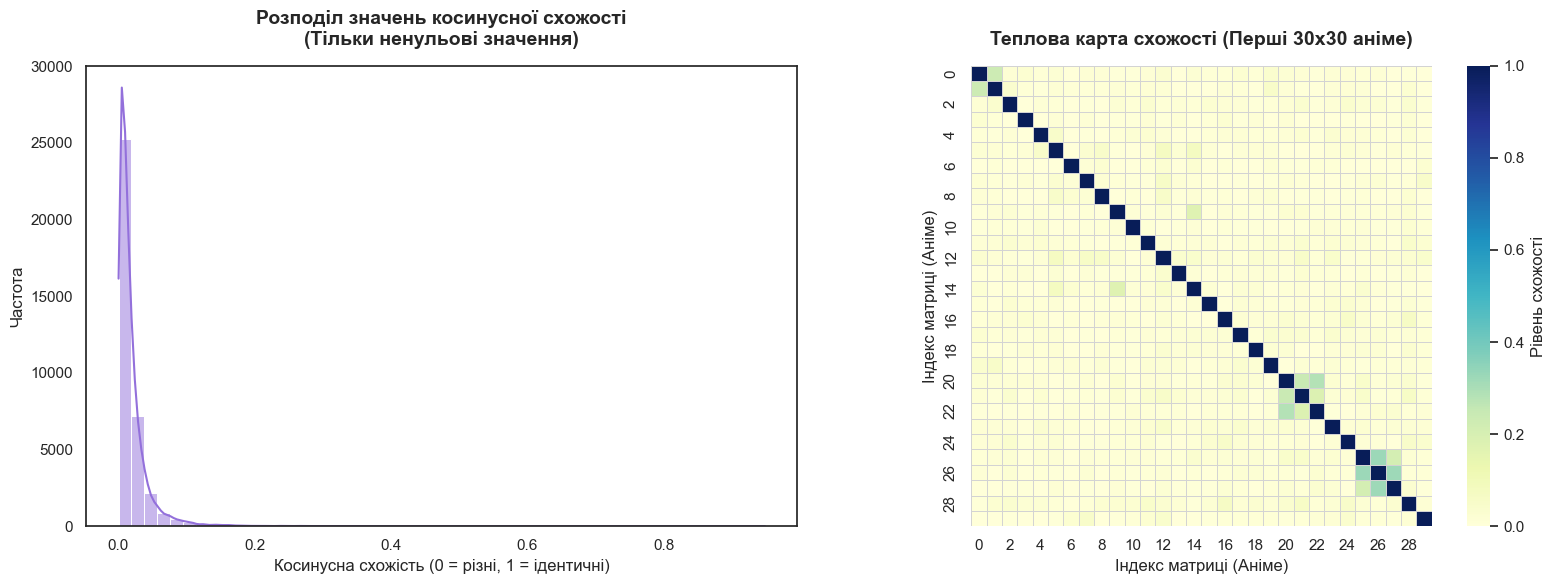

In [11]:

import scipy.sparse as sp

# Налаштування стилю
sns.set_theme(style="white")

print("Крок 1: Аналіз структури cosine_sim...")

# 1. Базова статистика
is_sparse = sp.issparse(cosine_sim)
print(f"Тип об'єкта: {type(cosine_sim)}")
print(f"Розмірність (Shape): {cosine_sim.shape}")

# 2. Безпечне отримання даних для графіків
# Щоб не перевантажити пам'ять, беремо вибірку для гістограми та фрагмент для теплової карти
sample_size = 30 # Розмір фрагмента для Heatmap

if is_sparse:
    print(f"Формат: Розріджена матриця (Sparse). Ненульових елементів: {cosine_sim.nnz}")
    # Витягуємо тільки ненульові значення для гістограми
    vals = cosine_sim.data
    # Беремо підматрицю для теплової карти і перетворюємо у звичайний numpy array
    sample_matrix = cosine_sim[:sample_size, :sample_size].toarray()
else:
    print(f"Формат: Щільна матриця (Dense). Розмір у пам'яті: ~{cosine_sim.nbytes / (1024**2):.1f} MB")
    # Беремо верхній трикутник (без діагоналі), щоб не враховувати схожість аніме самого з собою (1.0)
    upper_tri_indices = np.triu_indices_from(cosine_sim, k=1)
    vals = cosine_sim[upper_tri_indices]
    sample_matrix = cosine_sim[:sample_size, :sample_size]

# Беремо випадкові 100 000 значень для гістограми (щоб графіка будувалася швидко)
sample_vals = np.random.choice(vals, size=min(len(vals), 100000), replace=False)

print(f"Середня схожість між будь-якими двома аніме: {np.mean(vals):.6f}")
if len(vals[vals < 0.99]) > 0:
    print(f"Максимальна виявлена схожість (не враховуючи копії): {np.max(vals[vals < 0.99]):.6f}")

print(f"Мінімальна схожість: {np.min(vals):.6f}")

# 3. Побудова графіків
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Графік 1: Гістограма розподілу схожості
# Фільтруємо нулі, щоб вони не зіпсували масштаб графіка
non_zero_sample = sample_vals[sample_vals > 0]
sns.histplot(non_zero_sample, bins=50, ax=axes[0], color='mediumpurple', kde=True)
axes[0].set_title('Розподіл значень косинусної схожості\n(Тільки ненульові значення)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Косинусна схожість (0 = різні, 1 = ідентичні)', fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)

# Графік 2: Теплова карта (Heatmap)
sns.heatmap(
    sample_matrix, 
    cmap='YlGnBu', 
    ax=axes[1], 
    cbar_kws={'label': 'Рівень схожості'}, 
    square=True,
    linewidths=0.5,
    linecolor='lightgray'
)
axes[1].set_title(f'Теплова карта схожості (Перші {sample_size}x{sample_size} аніме)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Індекс матриці (Аніме)', fontsize=12)
axes[1].set_ylabel('Індекс матриці (Аніме)', fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
print("Крок 1: Підготовка до створення словника...")

# 1. Створюємо зворотний словник: індекс_у_матриці -> anime_id
index_to_anime = {idx: aid for aid, idx in indices.items()}

# 2. Перетворюємо valid_anime_ids на set для миттєвого пошуку (O(1))
valid_anime_set = set(valid_anime_ids)

# 3. Ініціалізуємо головний словник
anime_similarity_map = {}

print(f"Крок 2: Обробка {len(valid_anime_set)} аніме...")

# 4. Головний цикл
for aid in tqdm(valid_anime_set, desc="Створення хеш-мепи схожості"):
    idx = indices[aid]
    
    # Отримуємо рядок схожості для поточного аніме
    # (Підтримує як Dense, так і Sparse формати)
    if hasattr(cosine_sim, 'toarray'):
        row = cosine_sim[idx].toarray().flatten()
    else:
        row = cosine_sim[idx]
        
    # ВЕКТОРНА ФІЛЬТРАЦІЯ: Знаходимо індекси тільки тих аніме, де схожість >= 0.01
    valid_sim_indices = np.where(row >= 0.01)[0]
    
    # Формуємо внутрішній словник
    inner_dict = {}
    for sim_idx in valid_sim_indices:
        sim_aid = index_to_anime[sim_idx]
        
        # Перевіряємо, чи є це аніме валідним
        # Також відкидаємо схожість аніме із самим собою (sim_aid != aid), 
        # адже нам не треба рекомендувати користувачу те, що він і так зараз дивиться
        if sim_aid in valid_anime_set and sim_aid != aid:
            # Округлюємо до 4 знаків після коми
            inner_dict[sim_aid] = round(float(row[sim_idx]), 4)
            
    # Додаємо у головний словник тільки якщо є хоча б один збіг
    if inner_dict:
        anime_similarity_map[aid] = inner_dict

# 5. Збереження результату
# Вкажіть ваш шлях, наприклад output_dir
output_path = os.path.join(output_dir, 'anime_similarity_map.pkl')

with open(output_path, 'wb') as f:
    pickle.dump(anime_similarity_map, f)

print(f"\n✅ УСЕ ГОТОВО! Словник збережено: {output_path}")
print(f"Кількість аніме, які мають хоча б одного 'сусіда': {len(anime_similarity_map)}")

# Виведемо приклад для перевірки
sample_aid = list(anime_similarity_map.keys())[0]
print(f"\nПриклад структури для anime_id {sample_aid}:")
# Виводимо перші 5 елементів з внутрішнього словника
sample_items = list(anime_similarity_map[sample_aid].items())[:5]
print(sample_items)

Крок 1: Підготовка до створення словника...
Крок 2: Обробка 15462 аніме...


NameError: name 'tqdm' is not defined

In [ ]:
print("Очищення контентного словника...")

optimized_similarity_map = {}
NEW_THRESHOLD = 0.1
# MAX_NEIGHBORS = 100

for aid, neighbors in anime_similarity_map.items():
    # 1. Відфільтровуємо слабкі зв'язки
    filtered_neighbors = {k: v for k, v in neighbors.items() if v >= NEW_THRESHOLD}

    if filtered_neighbors:
        optimized_similarity_map[aid] = filtered_neighbors

# Аналізуємо новий словник
new_counts = [len(v) for v in optimized_similarity_map.values()]

print(f"\n--- Результати оптимізації ---")
print(f"Аніме, що мають хоча б 1 сусіда: {len(new_counts)} (з 15462)")
print(f"Нова СЕРЕДНЯ кількість сусідів: {np.mean(new_counts):.1f}")
print(f"Нова МЕДІАННА кількість сусідів: {np.median(new_counts):.1f}")

# Перезберігаємо словник
import pickle
with open(os.path.join(data_dir, 'anime_similarity_map_optimized.pkl'), 'wb') as f:
    pickle.dump(optimized_similarity_map, f)
print("✅ Оптимізований словник збережено!")

Очищення контентного словника...

--- Результати оптимізації ---
Аніме, що мають хоча б 1 сусіда: 15389 (з 15462)
Нова СЕРЕДНЯ кількість сусідів: 98.0
Нова МЕДІАННА кількість сусідів: 35.0
✅ Оптимізований словник збережено!


Аналіз кількості сусідів у optimized_similarity_map...
Загальна кількість аніме, що мають хоча б 1 сусіда: 15389
Середня кількість сусідів: 98.0
Медіанна кількість сусідів: 35.0
Максимальна кількість сусідів (найбільш 'типове' аніме): 1032
Мінімальна кількість сусідів (з тих, що мають хоч когось): 1


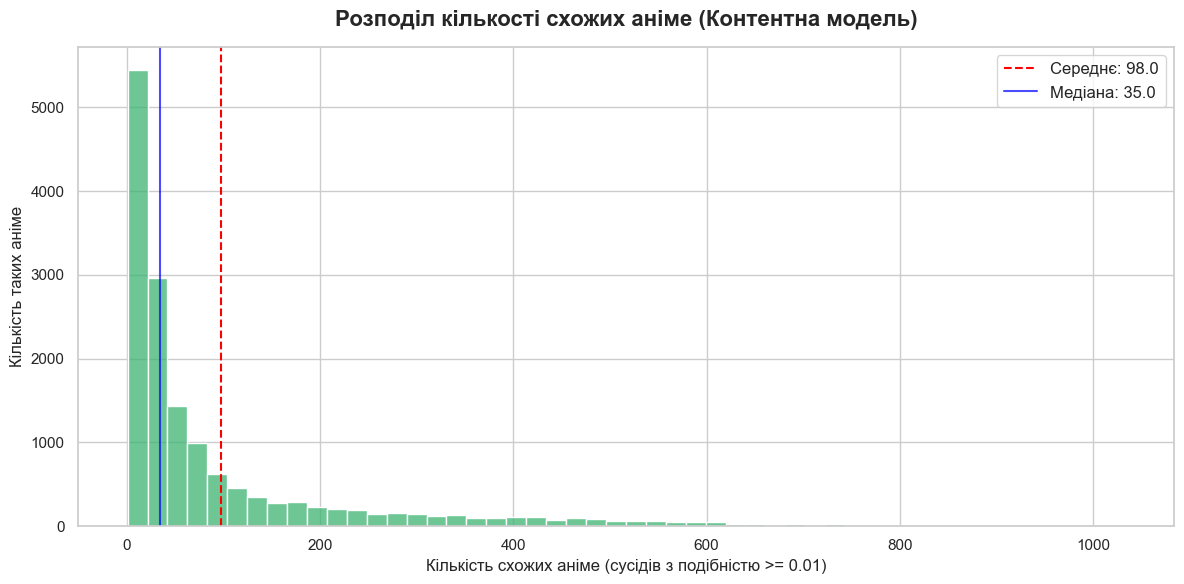

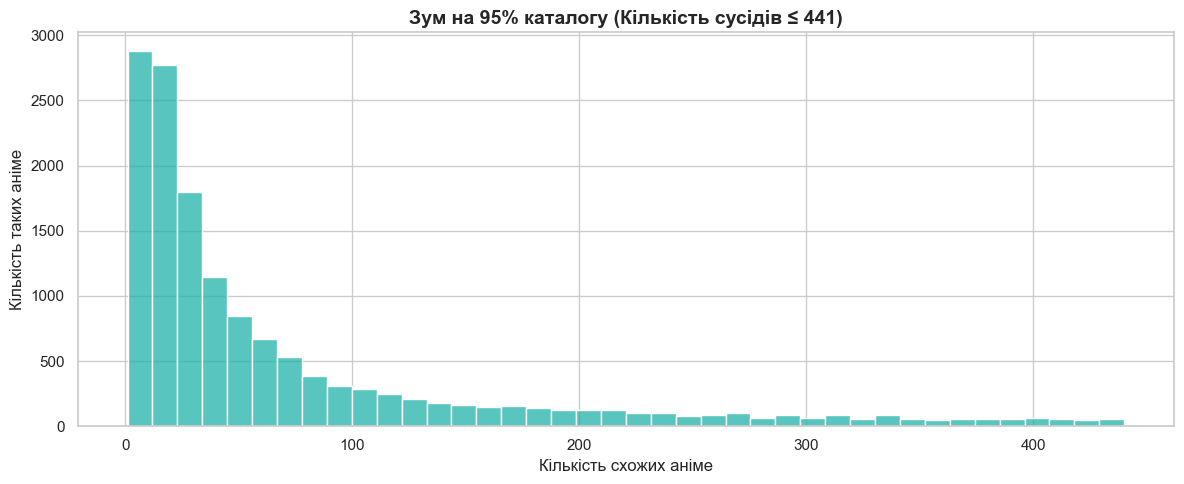

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Налаштування стилю
sns.set_theme(style="whitegrid")

print("Аналіз кількості сусідів у optimized_similarity_map...")

# 1. Рахуємо кількість сусідів для кожного аніме
# Використовуємо словник optimized_similarity_map, який вже є в пам'яті
neighbors_counts = [len(similar_items) for similar_items in optimized_similarity_map.values()]

# Базова статистика
print(f"Загальна кількість аніме, що мають хоча б 1 сусіда: {len(neighbors_counts)}")
print(f"Середня кількість сусідів: {np.mean(neighbors_counts):.1f}")
print(f"Медіанна кількість сусідів: {np.median(neighbors_counts):.1f}")
print(f"Максимальна кількість сусідів (найбільш 'типове' аніме): {np.max(neighbors_counts)}")
print(f"Мінімальна кількість сусідів (з тих, що мають хоч когось): {np.min(neighbors_counts)}")

# 2. Побудова гістограми
plt.figure(figsize=(12, 6))

# Будуємо графік. 
# Оскільки максимальна кількість може бути дуже великою (сотні), ми обмежимо вісь X 
# для кращої видимості (наприклад, 95-м перцентилем), але спочатку покажемо все
sns.histplot(neighbors_counts, bins=50, color='mediumseagreen', kde=False)

plt.title('Розподіл кількості схожих аніме (Контентна модель)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Кількість схожих аніме (сусідів з подібністю >= 0.01)', fontsize=12)
plt.ylabel('Кількість таких аніме', fontsize=12)

# Додаємо вертикальні лінії для середнього та медіани
plt.axvline(np.mean(neighbors_counts), color='red', linestyle='--', label=f'Середнє: {np.mean(neighbors_counts):.1f}')
plt.axvline(np.median(neighbors_counts), color='blue', linestyle='-', alpha=0.7, label=f'Медіана: {np.median(neighbors_counts):.1f}')

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 3. Додатковий фокус (Зум на більшість даних)
# Якщо є викиди (аніме з 1000+ сусідів), основний графік може бути важко читати.
# Побудуємо ще один графік для 95% найпоширеніших значень
p95 = np.percentile(neighbors_counts, 95)
plt.figure(figsize=(12, 5))
sns.histplot([x for x in neighbors_counts if x <= p95], bins=40, color='lightseagreen')
plt.title(f'Зум на 95% каталогу (Кількість сусідів ≤ {p95:.0f})', fontsize=14, fontweight='bold')
plt.xlabel('Кількість схожих аніме', fontsize=12)
plt.ylabel('Кількість таких аніме', fontsize=12)
plt.tight_layout()
plt.show()

In [1]:
import pickle
import os
# Вкажіть вашу папку, де лежать файли
data_dir = os.path.join('..', 'data')

# 2. Завантаження даних контентної моделі
svd_similarity_map_path = os.path.join(data_dir, 'svd_similarity_map_filtered.pkl')
with open(svd_similarity_map_path, 'rb') as f:
    svd_similarity_map = pickle.load(f)

In [7]:
print("Очищення контентного словника...")

optimized_svd_similarity_map = {}
NEW_THRESHOLD = 0.3
# MAX_NEIGHBORS = 100

for aid, neighbors in svd_similarity_map.items():
    # 1. Відфільтровуємо слабкі зв'язки
    filtered_neighbors = {k: v for k, v in neighbors.items() if v >= NEW_THRESHOLD}

    if filtered_neighbors:
        optimized_svd_similarity_map[aid] = filtered_neighbors

# Аналізуємо новий словник
new_counts = [len(v) for v in optimized_svd_similarity_map.values()]

print(f"\n--- Результати оптимізації ---")
print(f"Аніме, що мають хоча б 1 сусіда: {len(new_counts)} (з 15462)")
print(f"Нова СЕРЕДНЯ кількість сусідів: {np.mean(new_counts):.1f}")
print(f"Нова МЕДІАННА кількість сусідів: {np.median(new_counts):.1f}")

# Перезберігаємо словник
import pickle
with open(os.path.join(data_dir, 'svd_similarity_map_optimized.pkl'), 'wb') as f:
    pickle.dump(optimized_svd_similarity_map, f)
print("✅ Оптимізований словник збережено!")

Очищення контентного словника...

--- Результати оптимізації ---
Аніме, що мають хоча б 1 сусіда: 15424 (з 15462)
Нова СЕРЕДНЯ кількість сусідів: 282.3
Нова МЕДІАННА кількість сусідів: 123.0
✅ Оптимізований словник збережено!


Аналіз кількості сусідів у optimized_svd_similarity_map...
Загальна кількість аніме, що мають хоча б 1 сусіда: 15424
Середня кількість сусідів: 282.3
Медіанна кількість сусідів: 123.0
Максимальна кількість сусідів (найбільш 'типове' аніме): 2674
Мінімальна кількість сусідів (з тих, що мають хоч когось): 1


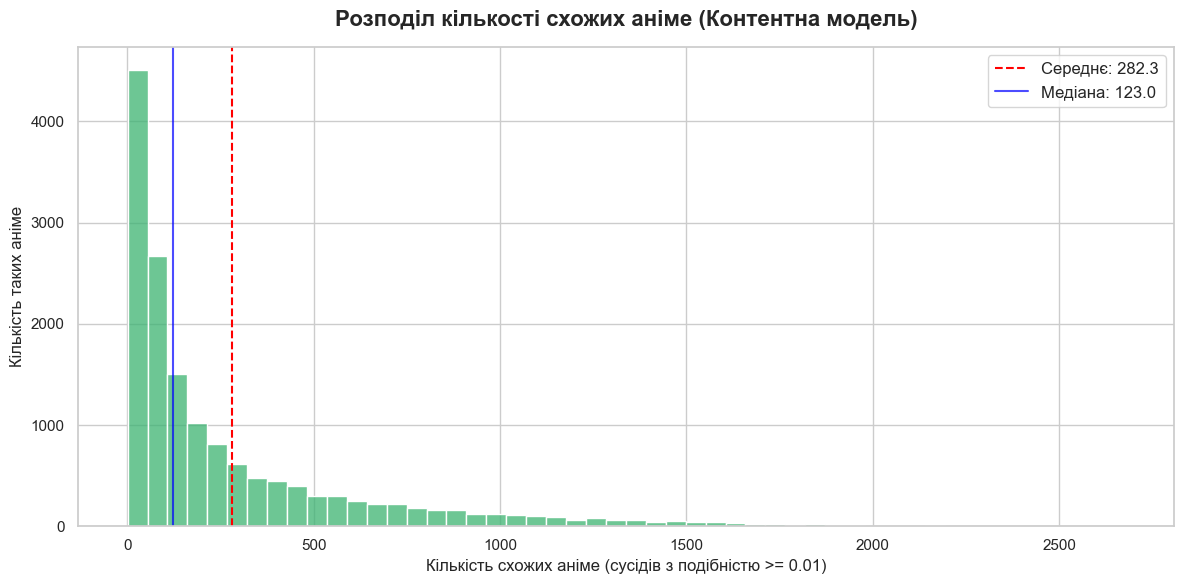

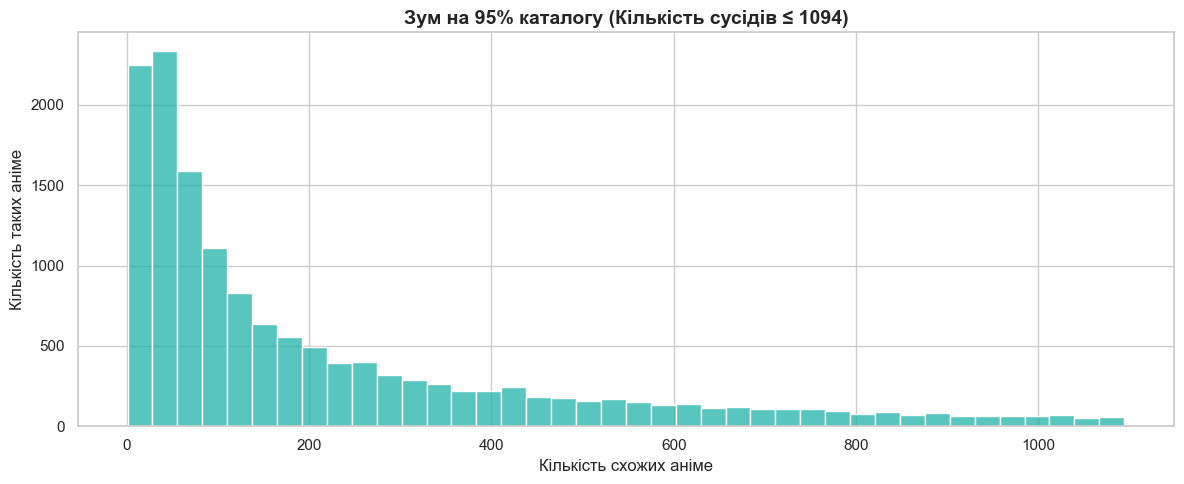

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Налаштування стилю
sns.set_theme(style="whitegrid")

print("Аналіз кількості сусідів у optimized_svd_similarity_map...")

# 1. Рахуємо кількість сусідів для кожного аніме
# Використовуємо словник optimized_svd_similarity_map, який вже є в пам'яті
neighbors_counts = [len(similar_items) for similar_items in optimized_svd_similarity_map.values()]

# Базова статистика
print(f"Загальна кількість аніме, що мають хоча б 1 сусіда: {len(neighbors_counts)}")
print(f"Середня кількість сусідів: {np.mean(neighbors_counts):.1f}")
print(f"Медіанна кількість сусідів: {np.median(neighbors_counts):.1f}")
print(f"Максимальна кількість сусідів (найбільш 'типове' аніме): {np.max(neighbors_counts)}")
print(f"Мінімальна кількість сусідів (з тих, що мають хоч когось): {np.min(neighbors_counts)}")

# 2. Побудова г істограми
plt.figure(figsize=(12, 6))

# Будуємо графік. 
# Оскільки максимальна кількість може бути дуже великою (сотні), ми обмежимо вісь X 
# для кращої видимості (наприклад, 95-м перцентилем), але спочатку покажемо все
sns.histplot(neighbors_counts, bins=50, color='mediumseagreen', kde=False)

plt.title('Розподіл кількості схожих аніме (Контентна модель)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Кількість схожих аніме (сусідів з подібністю >= 0.01)', fontsize=12)
plt.ylabel('Кількість таких аніме', fontsize=12)

# Додаємо вертикальні лінії для середнього та медіани
plt.axvline(np.mean(neighbors_counts), color='red', linestyle='--', label=f'Середнє: {np.mean(neighbors_counts):.1f}')
plt.axvline(np.median(neighbors_counts), color='blue', linestyle='-', alpha=0.7, label=f'Медіана: {np.median(neighbors_counts):.1f}')

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 3. Додатковий фокус (Зум на більшість даних)
# Якщо є викиди (аніме з 1000+ сусідів), основний графік може бути важко читати.
# Побудуємо ще один графік для 95% найпоширеніших значень
p95 = np.percentile(neighbors_counts, 95)
plt.figure(figsize=(12, 5))
sns.histplot([x for x in neighbors_counts if x <= p95], bins=40, color='lightseagreen')
plt.title(f'Зум на 95% каталогу (Кількість сусідів ≤ {p95:.0f})', fontsize=14, fontweight='bold')
plt.xlabel('Кількість схожих аніме', fontsize=12)
plt.ylabel('Кількість таких аніме', fontsize=12)
plt.tight_layout()
plt.show()

In [1]:
import pickle
import os
import pandas as pd
dir_path = os.path.join('..', 'data')
with open(os.path.join(dir_path, 'anime_similarity_map_optimized.pkl'), 'rb') as f:
    anime_similarity_map_optimized = pickle.load(f)
with open(os.path.join(dir_path, 'svd_similarity_map_optimized.pkl'), 'rb') as f:
    svd_similarity_map_optimized = pickle.load(f)

In [2]:
weights_filepath = os.path.join(dir_path, 'hybrid_weights.pkl')
with open(weights_filepath, 'rb') as f:
    hybrid_weights = pickle.load(f)

w_collab = hybrid_weights['w_collab']
w_content = hybrid_weights['w_content']

In [4]:
anime_similarity_map_optimized[5]

{1: 0.2315, 17205: 0.1253, 40171: 0.1128}

In [8]:
svd_similarity_map_optimized[5][17205]

0.3102

In [ ]:
import pickle
from tqdm.auto import tqdm

print("--- Крок 1: Підготовка до гібридизації ---")

# Задаємо ваги (можете погратися з ними, 0.7 і 0.3 - стандартна хороша пропорція)
W_COLLAB = w_collab # Вага SVD
W_CONTENT = w_content # Вага TF-IDF


hybrid_similarity_map = {}

# 1. Створюємо список ВСІХ унікальних id аніме з обох мепів (використовуємо set для швидкості)
all_anime_ids = set(anime_similarity_map_optimized.keys()).union(set(svd_similarity_map_optimized.keys()))

print(f"Всього унікальних аніме для обробки: {len(all_anime_ids)}")
print(f"Гібридизація (SVD: {W_COLLAB}, Content: {W_CONTENT})...")

# 2. Проходимось по кожному аніме
for anime_id in tqdm(all_anime_ids, desc="Створення Гібридного Мепу"):
    
    # Дістаємо словники сусідів. Якщо аніме немає в якомусь мепі — беремо порожній словник {}
    content_neighbors = anime_similarity_map_optimized.get(anime_id, {})
    collab_neighbors = svd_similarity_map_optimized.get(anime_id, {})
    
    # 3. Створюємо список ВСІХ сусідів для цього конкретного аніме
    all_neighbors = set(content_neighbors.keys()).union(set(collab_neighbors.keys()))
    
    hybrid_neighbors = {}
    
    # 4. Проходимось по кожному сусіду
    for neighbor_id in all_neighbors:
        
        # Беремо бали. Якщо сусіда немає в якомусь з мепів, метод .get() поверне 0.0
        score_content = content_neighbors.get(neighbor_id, 0.0)
        score_collab = collab_neighbors.get(neighbor_id, 0.0)
        
        # 5. Гібридизація (математика відпрацює ідеально навіть якщо один з балів = 0.0)
        hybrid_score = (W_CONTENT * score_content) + (W_COLLAB * score_collab)
        
        # 6. Округлюємо та відкидаємо мікро-шум, щоб не роздувати словник
        if abs(hybrid_score) >= 0.01:
            hybrid_neighbors[neighbor_id] = round(hybrid_score, 4)
            
    # Якщо після гібридизації залишились сусіди, додаємо в загальний меп
    if hybrid_neighbors:
        hybrid_similarity_map[anime_id] = hybrid_neighbors

# --- Крок 3: Збереження результату ---
output_filename = 'hybrid_similarity_map_2.pkl'
with open(os.path.join(dir_path, output_filename), 'wb') as f:
    pickle.dump(hybrid_similarity_map, f)

print(f"\n✅ УСЕ ГОТОВО! Гібридний словник збережено у: {output_filename}")
print(f"Розмір гібридного словника (кількість аніме-ключів): {len(hybrid_similarity_map)}")

# Тест: дивимось приклад
sample_aid = list(hybrid_similarity_map.keys())[0]
print(f"\nПриклад гібридних зв'язків для Anime ID {sample_aid}:")
# Виводимо перші 5 відсортованих за балом сусідів
sample_items = sorted(hybrid_similarity_map[sample_aid].items(), key=lambda x: x[1], reverse=True)[:5]
print(sample_items)

--- Крок 1: Підготовка до гібридизації ---
Всього унікальних аніме для обробки: 17179
Гібридизація (SVD: 0.844646792868503, Content: 0.155353207131497)...


Створення Гібридного Мепу: 100%|██████████| 17179/17179 [00:05<00:00, 3080.51it/s]



✅ УСЕ ГОТОВО! Гібридний словник збережено у: hybrid_similarity_map_2.pkl
Розмір гібридного словника (кількість аніме-ключів): 17179

Приклад гібридних зв'язків для Anime ID 1:
[(5, 0.8739), (205, 0.6637), (7785, 0.4849), (400, 0.4787), (43, 0.4586)]


In [1]:
import pickle
import os
import pandas as pd
dir_path = os.path.join('..', 'data')
with open(os.path.join(dir_path, 'anime_similarity_map_optimized.pkl'), 'rb') as f:
    anime_similarity_map_optimized = pickle.load(f)
with open(os.path.join(dir_path, 'svd_similarity_map_optimized.pkl'), 'rb') as f:
    svd_similarity_map_optimized = pickle.load(f)
with open(os.path.join(dir_path, 'hybrid_similarity_map.pkl'), 'rb') as f:
    hybrid_similarity_map = pickle.load(f)

Аналіз кількості сусідів у anime_similarity_map_optimized...
Загальна кількість аніме, що мають хоча б 1 сусіда: 15389
Середня кількість сусідів: 98.0
Медіанна кількість сусідів: 35.0
Максимальна кількість сусідів (найбільш 'типове' аніме): 1032
Мінімальна кількість сусідів (з тих, що мають хоч когось): 1


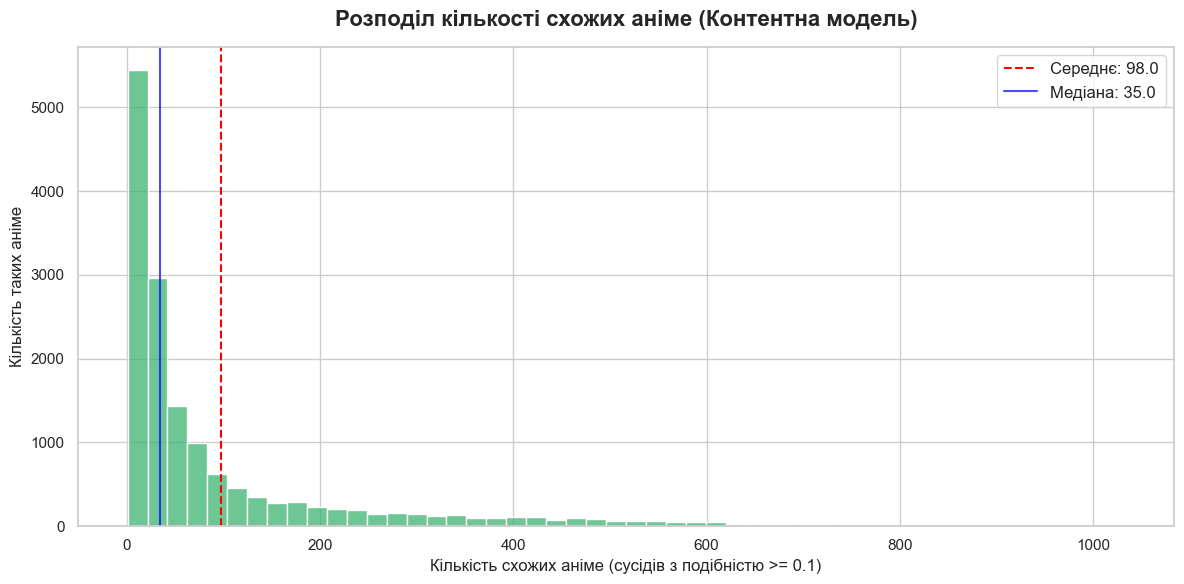

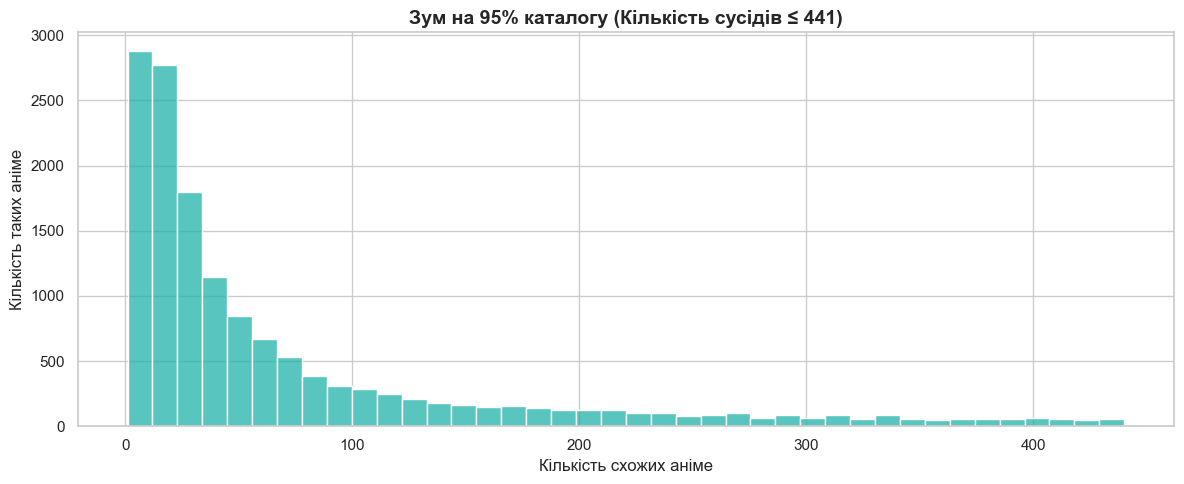

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Налаштування стилю
sns.set_theme(style="whitegrid")

print("Аналіз кількості сусідів у anime_similarity_map_optimized...")

# 1. Рахуємо кількість сусідів для кожного аніме
# Використовуємо словник anime_similarity_map_optimized, який вже є в пам'яті
neighbors_counts = [len(similar_items) for similar_items in anime_similarity_map_optimized.values()]

# Базова статистика
print(f"Загальна кількість аніме, що мають хоча б 1 сусіда: {len(neighbors_counts)}")
print(f"Середня кількість сусідів: {np.mean(neighbors_counts):.1f}")
print(f"Медіанна кількість сусідів: {np.median(neighbors_counts):.1f}")
print(f"Максимальна кількість сусідів (найбільш 'типове' аніме): {np.max(neighbors_counts)}")
print(f"Мінімальна кількість сусідів (з тих, що мають хоч когось): {np.min(neighbors_counts)}")

# 2. Побудова гістограми
plt.figure(figsize=(12, 6))

# Будуємо графік. 
# Оскільки максимальна кількість може бути дуже великою (сотні), ми обмежимо вісь X 
# для кращої видимості (наприклад, 95-м перцентилем), але спочатку покажемо все
sns.histplot(neighbors_counts, bins=50, color='mediumseagreen', kde=False)

plt.title('Розподіл кількості схожих аніме (Контентна модель)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Кількість схожих аніме (сусідів з подібністю >= 0.1)', fontsize=12)
plt.ylabel('Кількість таких аніме', fontsize=12)

# Додаємо вертикальні лінії для середнього та медіани
plt.axvline(np.mean(neighbors_counts), color='red', linestyle='--', label=f'Середнє: {np.mean(neighbors_counts):.1f}')
plt.axvline(np.median(neighbors_counts), color='blue', linestyle='-', alpha=0.7, label=f'Медіана: {np.median(neighbors_counts):.1f}')

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 3. Додатковий фокус (Зум на більшість даних)
# Якщо є викиди (аніме з 1000+ сусідів), основний графік може бути важко читати.
# Побудуємо ще один графік для 95% найпоширеніших значень
p95 = np.percentile(neighbors_counts, 95)
plt.figure(figsize=(12, 5))
sns.histplot([x for x in neighbors_counts if x <= p95], bins=40, color='lightseagreen')
plt.title(f'Зум на 95% каталогу (Кількість сусідів ≤ {p95:.0f})', fontsize=14, fontweight='bold')
plt.xlabel('Кількість схожих аніме', fontsize=12)
plt.ylabel('Кількість таких аніме', fontsize=12)
plt.tight_layout()
plt.show()

Аналіз кількості сусідів у svd_similarity_map_optimized...
Загальна кількість аніме, що мають хоча б 1 сусіда: 15424
Середня кількість сусідів: 282.3
Медіанна кількість сусідів: 123.0
Максимальна кількість сусідів (найбільш 'типове' аніме): 2674
Мінімальна кількість сусідів (з тих, що мають хоч когось): 1


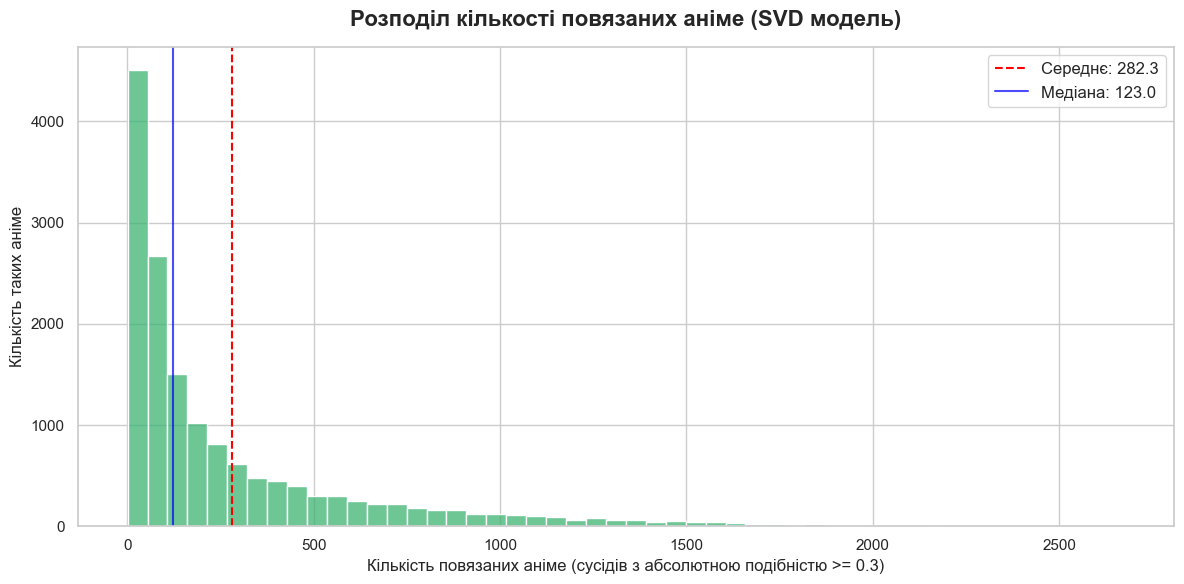

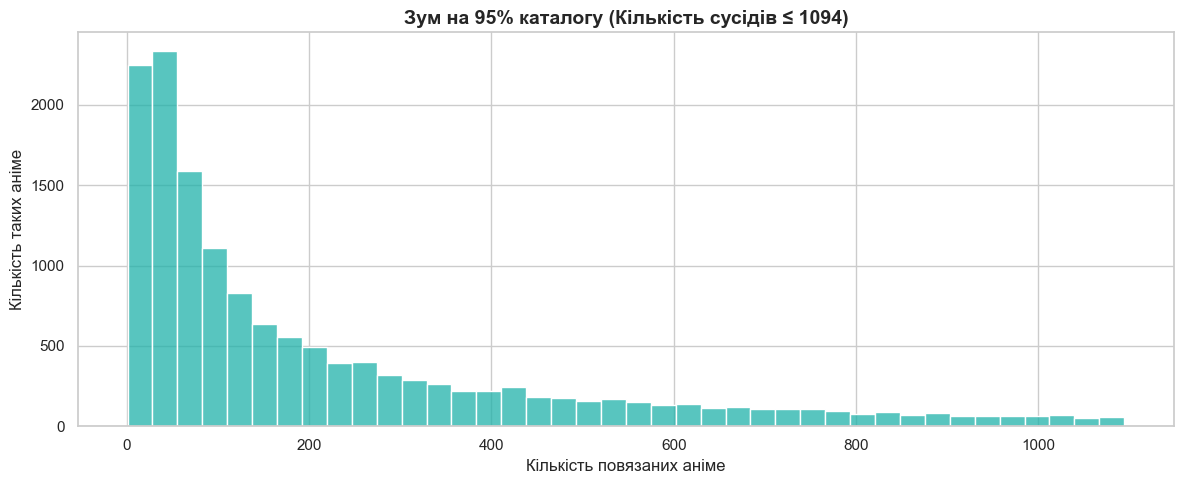

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Налаштування стилю
sns.set_theme(style="whitegrid")

print("Аналіз кількості сусідів у svd_similarity_map_optimized...")

# 1. Рахуємо кількість сусідів для кожного аніме
# Використовуємо словник svd_similarity_map_optimized, який вже є в пам'яті
neighbors_counts = [len(similar_items) for similar_items in svd_similarity_map_optimized.values()]

# Базова статистика
print(f"Загальна кількість аніме, що мають хоча б 1 сусіда: {len(neighbors_counts)}")
print(f"Середня кількість сусідів: {np.mean(neighbors_counts):.1f}")
print(f"Медіанна кількість сусідів: {np.median(neighbors_counts):.1f}")
print(f"Максимальна кількість сусідів (найбільш 'типове' аніме): {np.max(neighbors_counts)}")
print(f"Мінімальна кількість сусідів (з тих, що мають хоч когось): {np.min(neighbors_counts)}")

# 2. Побудова г істограми
plt.figure(figsize=(12, 6))

# Будуємо графік. 
# Оскільки максимальна кількість може бути дуже великою (сотні), ми обмежимо вісь X 
# для кращої видимості (наприклад, 95-м перцентилем), але спочатку покажемо все
sns.histplot(neighbors_counts, bins=50, color='mediumseagreen', kde=False)

plt.title('Розподіл кількості повязаних аніме (SVD модель)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Кількість повязаних аніме (сусідів з абсолютною подібністю >= 0.3)', fontsize=12)
plt.ylabel('Кількість таких аніме', fontsize=12)

# Додаємо вертикальні лінії для середнього та медіани
plt.axvline(np.mean(neighbors_counts), color='red', linestyle='--', label=f'Середнє: {np.mean(neighbors_counts):.1f}')
plt.axvline(np.median(neighbors_counts), color='blue', linestyle='-', alpha=0.7, label=f'Медіана: {np.median(neighbors_counts):.1f}')

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 3. Додатковий фокус (Зум на більшість даних)
# Якщо є викиди (аніме з 1000+ сусідів), основний графік може бути важко читати.
# Побудуємо ще один графік для 95% найпоширеніших значень
p95 = np.percentile(neighbors_counts, 95)
plt.figure(figsize=(12, 5))
sns.histplot([x for x in neighbors_counts if x <= p95], bins=40, color='lightseagreen')
plt.title(f'Зум на 95% каталогу (Кількість сусідів ≤ {p95:.0f})', fontsize=14, fontweight='bold')
plt.xlabel('Кількість повязаних аніме', fontsize=12)
plt.ylabel('Кількість таких аніме', fontsize=12)
plt.tight_layout()
plt.show()

Аналіз кількості сусідів у hybrid_similarity_map...
Загальна кількість аніме, що мають хоча б 1 сусіда: 17179
Середня кількість сусідів: 336.5
Медіанна кількість сусідів: 179.0
Максимальна кількість сусідів (найбільш 'типове' аніме): 2992
Мінімальна кількість сусідів (з тих, що мають хоч когось): 1


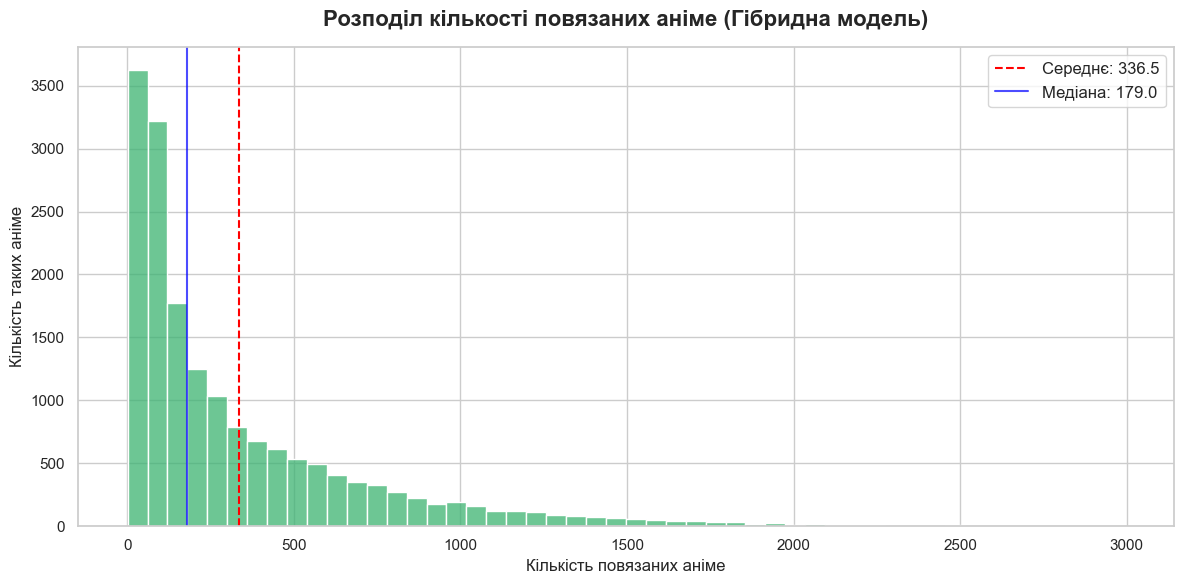

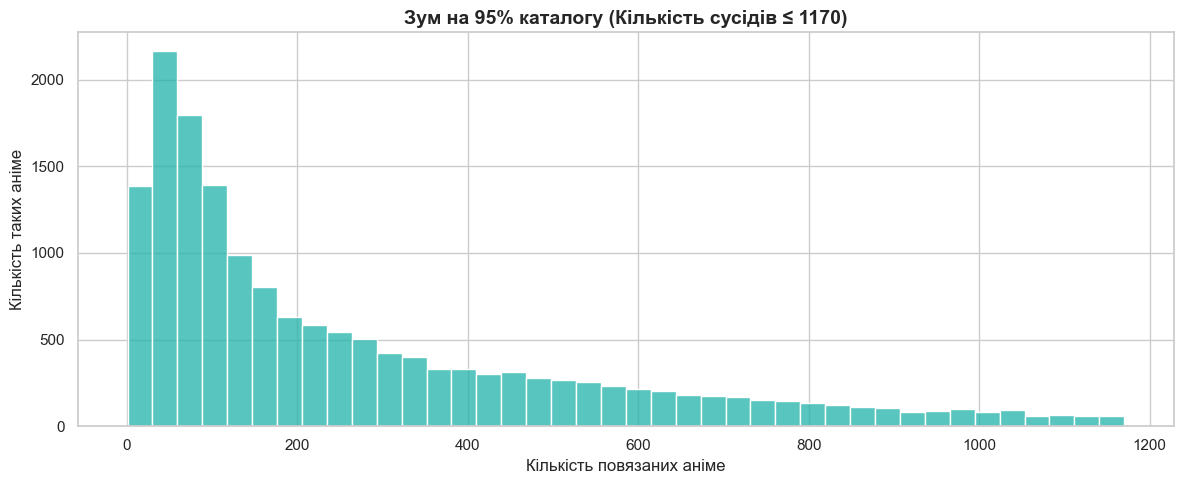

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Налаштування стилю
sns.set_theme(style="whitegrid")

print("Аналіз кількості сусідів у hybrid_similarity_map...")

# 1. Рахуємо кількість сусідів для кожного аніме
# Використовуємо словник hybrid_similarity_map, який вже є в пам'яті
neighbors_counts = [len(similar_items) for similar_items in hybrid_similarity_map.values()]

# Базова статистика
print(f"Загальна кількість аніме, що мають хоча б 1 сусіда: {len(neighbors_counts)}")
print(f"Середня кількість сусідів: {np.mean(neighbors_counts):.1f}")
print(f"Медіанна кількість сусідів: {np.median(neighbors_counts):.1f}")
print(f"Максимальна кількість сусідів (найбільш 'типове' аніме): {np.max(neighbors_counts)}")
print(f"Мінімальна кількість сусідів (з тих, що мають хоч когось): {np.min(neighbors_counts)}")

# 2. Побудова г істограми
plt.figure(figsize=(12, 6))

# Будуємо графік. 
# Оскільки максимальна кількість може бути дуже великою (сотні), ми обмежимо вісь X 
# для кращої видимості (наприклад, 95-м перцентилем), але спочатку покажемо все
sns.histplot(neighbors_counts, bins=50, color='mediumseagreen', kde=False)

plt.title('Розподіл кількості повязаних аніме (Гібридна модель)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Кількість повязаних аніме', fontsize=12)
plt.ylabel('Кількість таких аніме', fontsize=12)

# Додаємо вертикальні лінії для середнього та медіани
plt.axvline(np.mean(neighbors_counts), color='red', linestyle='--', label=f'Середнє: {np.mean(neighbors_counts):.1f}')
plt.axvline(np.median(neighbors_counts), color='blue', linestyle='-', alpha=0.7, label=f'Медіана: {np.median(neighbors_counts):.1f}')

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 3. Додатковий фокус (Зум на більшість даних)
# Якщо є викиди (аніме з 1000+ сусідів), основний графік може бути важко читати.
# Побудуємо ще один графік для 95% найпоширеніших значень
p95 = np.percentile(neighbors_counts, 95)
plt.figure(figsize=(12, 5))
sns.histplot([x for x in neighbors_counts if x <= p95], bins=40, color='lightseagreen')
plt.title(f'Зум на 95% каталогу (Кількість сусідів ≤ {p95:.0f})', fontsize=14, fontweight='bold')
plt.xlabel('Кількість повязаних аніме', fontsize=12)
plt.ylabel('Кількість таких аніме', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
output_dir = os.path.join('..', 'data')
all_models_ranking_metrics = pd.read_parquet(os.path.join(output_dir, "all_models_ranking_metrics.parquet"))
keras_metrics_df = pd.read_parquet(os.path.join(output_dir, "keras_baselines_metrics.parquet"))
all_models_ranking_metrics = pd.merge(all_models_ranking_metrics, keras_metrics_df, on=['user_id', 'train_count'], how='inner')

In [15]:
rt_metrics_df = pd.read_parquet(os.path.join(output_dir, "rt_metrics_df.parquet"))

In [16]:
rt_metrics_df = rt_metrics_df.rename(columns={
    'Precision@10': 'RT_Precision@10',
    'Recall@10': 'RT_Recall@10',
    'MRR': 'RT_MRR',
    'AUC': 'RT_AUC'
})

In [17]:
all_models_ranking_metrics = pd.merge(all_models_ranking_metrics, rt_metrics_df, on=['user_id', 'train_count'], how='inner')

C:\Users\Anton\AppData\Local\Temp\ipykernel_15504\2744434539.py:35: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


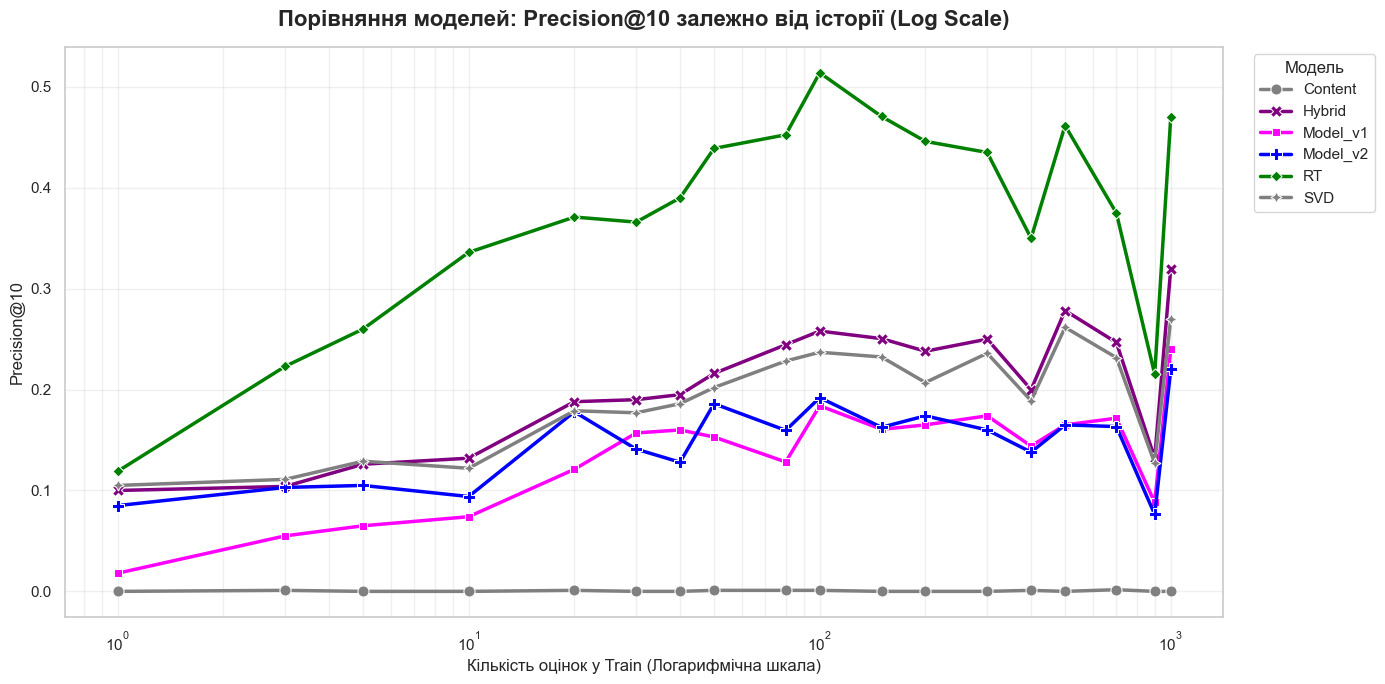

C:\Users\Anton\AppData\Local\Temp\ipykernel_15504\2744434539.py:35: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


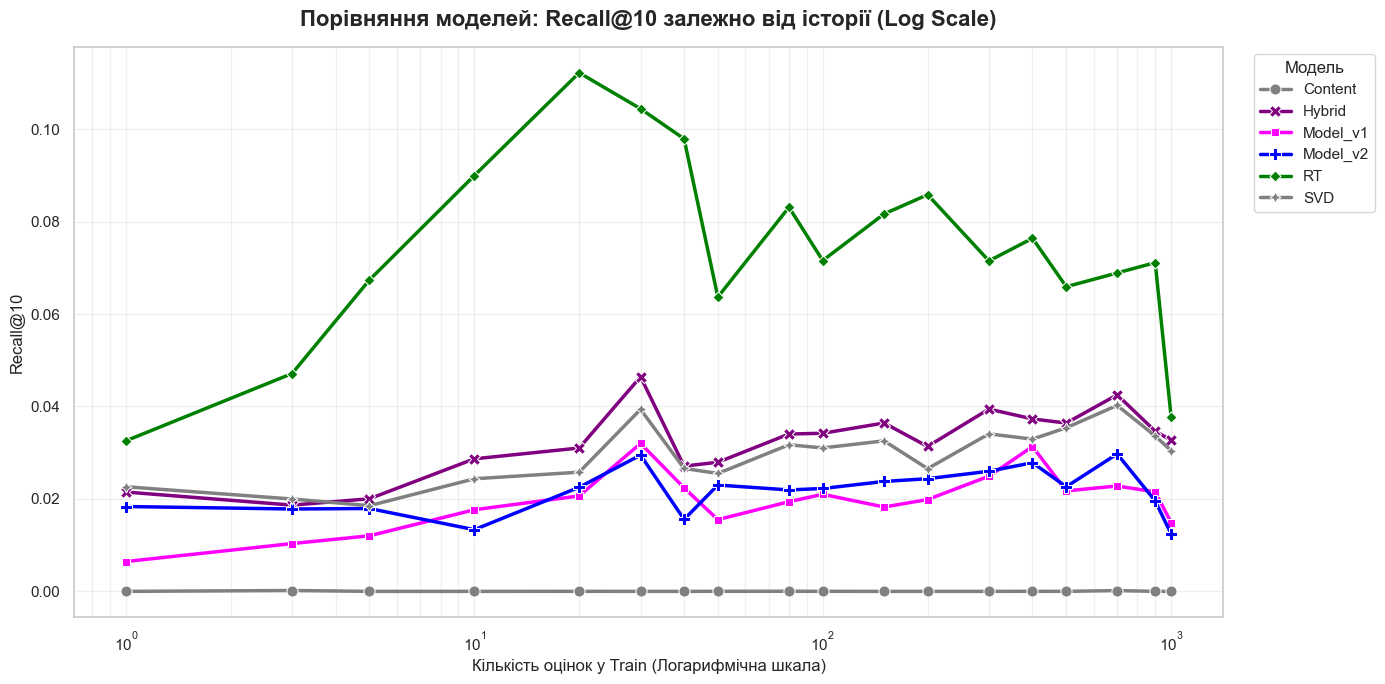

C:\Users\Anton\AppData\Local\Temp\ipykernel_15504\2744434539.py:35: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


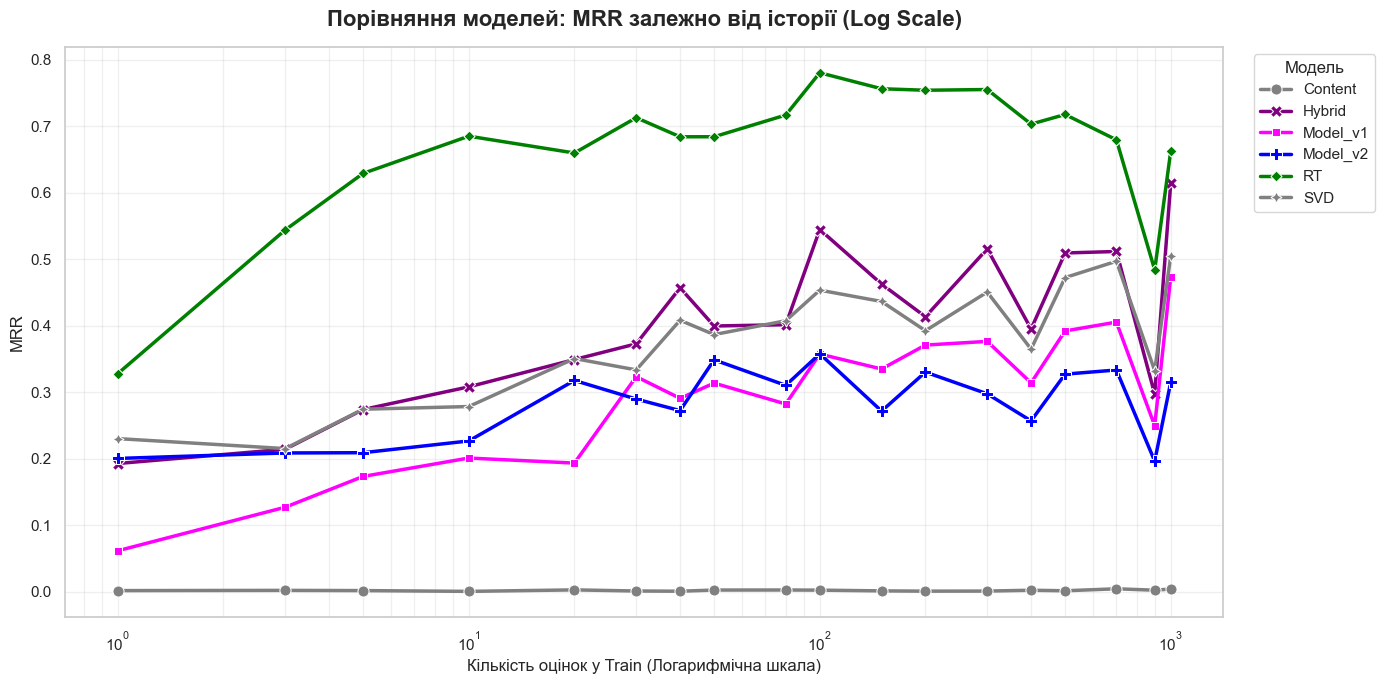

C:\Users\Anton\AppData\Local\Temp\ipykernel_15504\2744434539.py:35: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


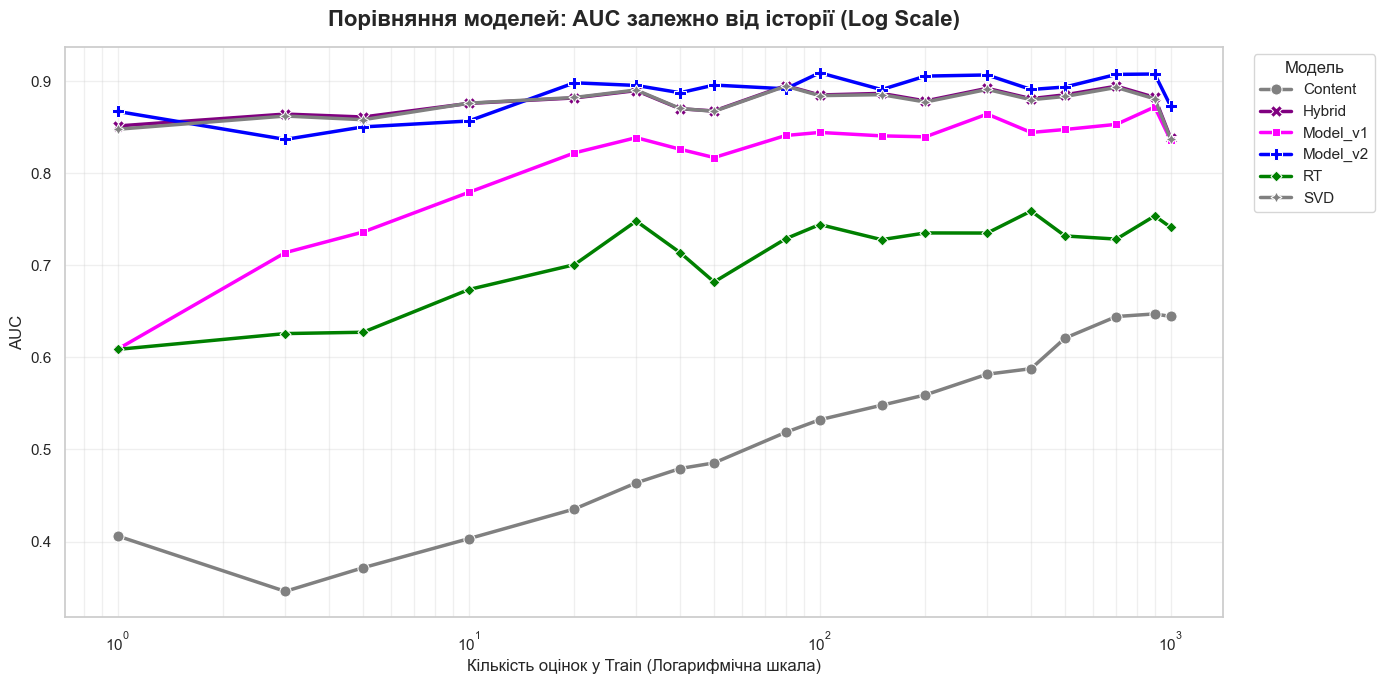

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Підготовка даних: злиття all_models_ranking_metrics з кількістю оцінок в train
# Припускаємо, що в all_models_ranking_metrics є колонка 'train_count'
models_list = ['SVD', 'Content', 'Hybrid', 'Model_v1', 'Model_v2', 'RT']
ref_counts = [1, 3, 5, 10, 20, 30, 40, 50, 80, 100, 150, 200, 300, 400, 500, 700, 900, 1000]
df_plot = all_models_ranking_metrics[all_models_ranking_metrics['train_count'].isin(ref_counts)].copy()

metrics_to_plot = ['Precision@10', 'Recall@10', 'MRR', 'AUC']
colors = ['grey', 'purple', 'magenta', 'blue', 'green'] # Кольори для 6 моделей

# Запускаємо цикл: кожна ітерація - це новий, окремий графік
for metric in metrics_to_plot:
    # Створюємо нове, повністю незалежне полотно
    plt.figure(figsize=(14, 7))
    
    # Збираємо дані для однієї метрики з усіх моделей
    cols_to_melt = [f"{model}_{metric}" for model in models_list]
    
    df_metric_melted = df_plot.melt(
        id_vars=['train_count'],
        value_vars=cols_to_melt,
        var_name='Model',
        value_name='Value'
    )
    
    # Очищуємо назви моделей для легенди (видаляємо суфікс метрики, наприклад "_Precision@10")
    df_metric_melted['Model'] = df_metric_melted['Model'].str.replace(f'_{metric}', '')
    
    # Рахуємо середнє значення для кожної референсної точки
    trend_data = df_metric_melted.groupby(['train_count', 'Model'])['Value'].mean().reset_index()
    
    # Побудова графіка
    sns.lineplot(
        data=trend_data, 
        x='train_count', 
        y='Value', 
        hue='Model', 
        style='Model', 
        markers=True, 
        dashes=False, 
        linewidth=2.5,
        palette=colors,
        markersize=8
    )
    
    # Налаштування осей та краси
    plt.xscale('log')
    plt.title(f'Порівняння моделей: {metric} залежно від історії (Log Scale)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Кількість оцінок у Train (Логарифмічна шкала)', fontsize=12)
    plt.ylabel(metric, fontsize=12)
    
    # Виносимо легенду за межі графіка, щоб вона не перекривала лінії
    plt.legend(title='Модель', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
    plt.grid(True, which="both", alpha=0.3)
    
    plt.tight_layout()
    
    # Виводимо графік на екран (це розділяє їх у Jupyter Notebook)
    plt.show()
    
    # Додаємо візуальний роздільник між виводами
    print("\n" + "="*80 + "\n")

In [ ]:
rt_metrics_df = pd.read_parquet(os.path.join(output_dir, "rt_metrics_df.parquet"))

In [24]:
rt_metrics_df

,RT_Precision@10,RT_Recall@10,RT_MRR,RT_AUC,user_id,train_count
0,0.0,0.000000,0.035714,0.774931,371,900.0
1,0.8,0.080000,1.000000,0.610738,716,50.0
2,0.7,0.031532,1.000000,0.651013,871,80.0
3,0.2,0.117647,0.333333,0.660714,876,900.0
4,0.5,0.016181,1.000000,0.750429,1396,100.0
...,...,...,...,...,...,...
1582,0.2,0.040816,1.000000,0.354285,352942,5.0
1583,0.1,0.005952,0.500000,0.684290,353021,5.0
1584,0.1,0.026316,1.000000,0.835547,353065,10.0
1585,0.0,0.000000,0.090909,0.914683,353264,20.0


In [22]:
output_dir = os.path.join('..', 'data', 'processed')
active_learning_metrics = pd.read_parquet(os.path.join(output_dir, "active_learning_metrics.parquet"))

In [23]:
active_learning_metrics

,Precision@10,Recall@10,MRR,AUC,user_id,asked_count,profile_size
0,0.7,0.038462,1.000000,0.681518,371,1,1
1,0.9,0.049724,1.000000,0.690838,371,3,2
2,0.9,0.049724,1.000000,0.690838,371,5,2
3,0.6,0.033708,1.000000,0.695215,371,10,5
4,0.7,0.039773,1.000000,0.713601,371,20,8
...,...,...,...,...,...,...,...
28591,0.1,0.002347,0.200000,0.720799,353395,400,54
28592,0.1,0.002387,0.142857,0.722794,353395,500,64
28593,0.0,0.000000,0.083333,0.728791,353395,700,83
28594,0.1,0.002584,0.111111,0.748545,353395,900,101


Генерація порівняльних графіків...


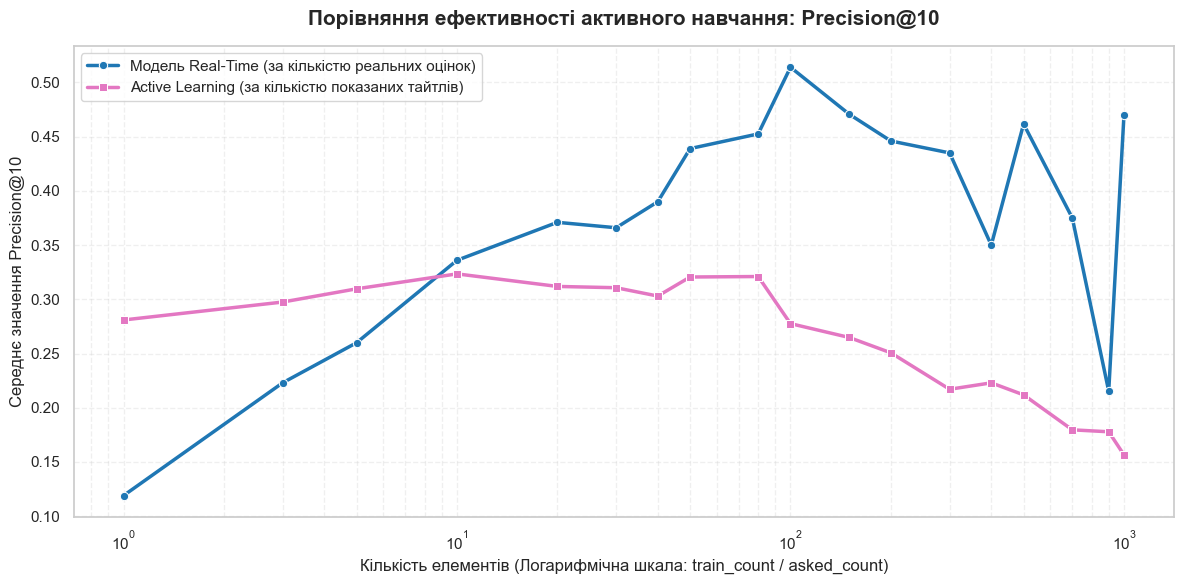

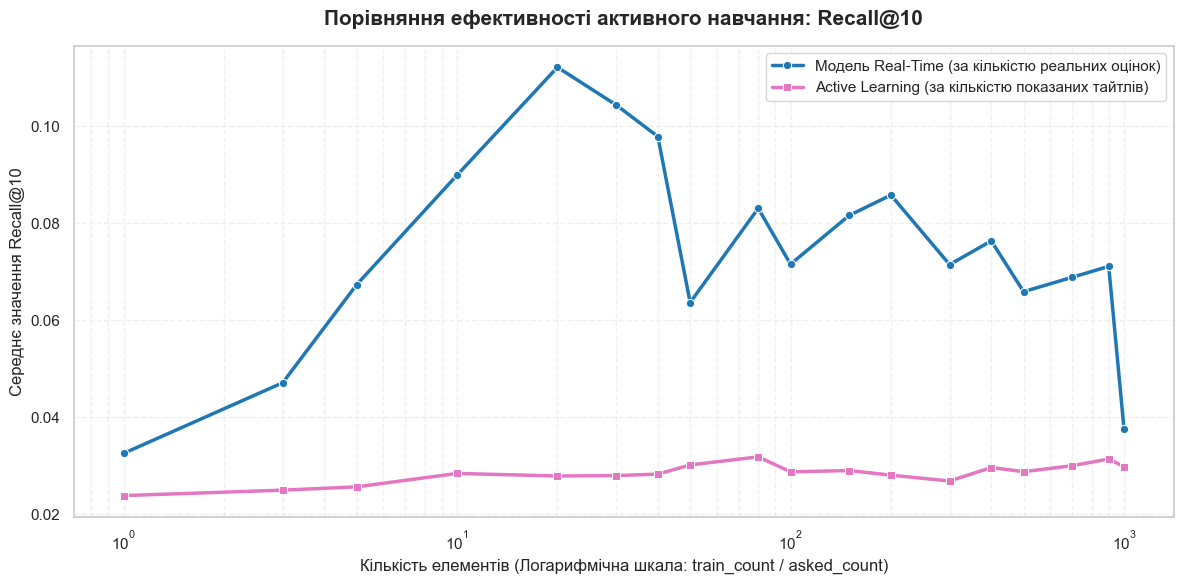

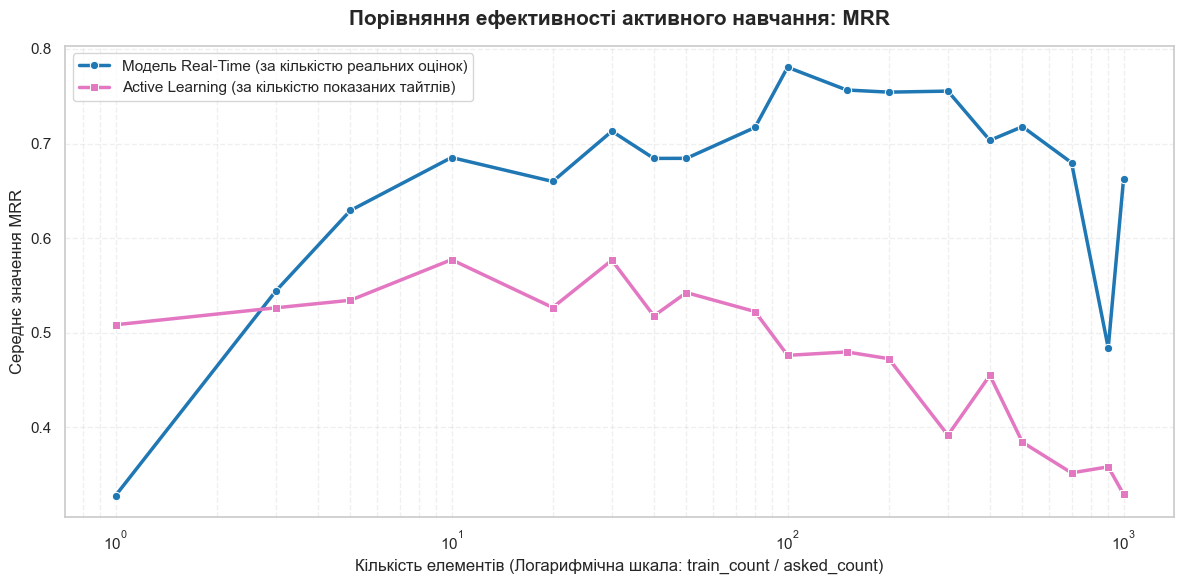

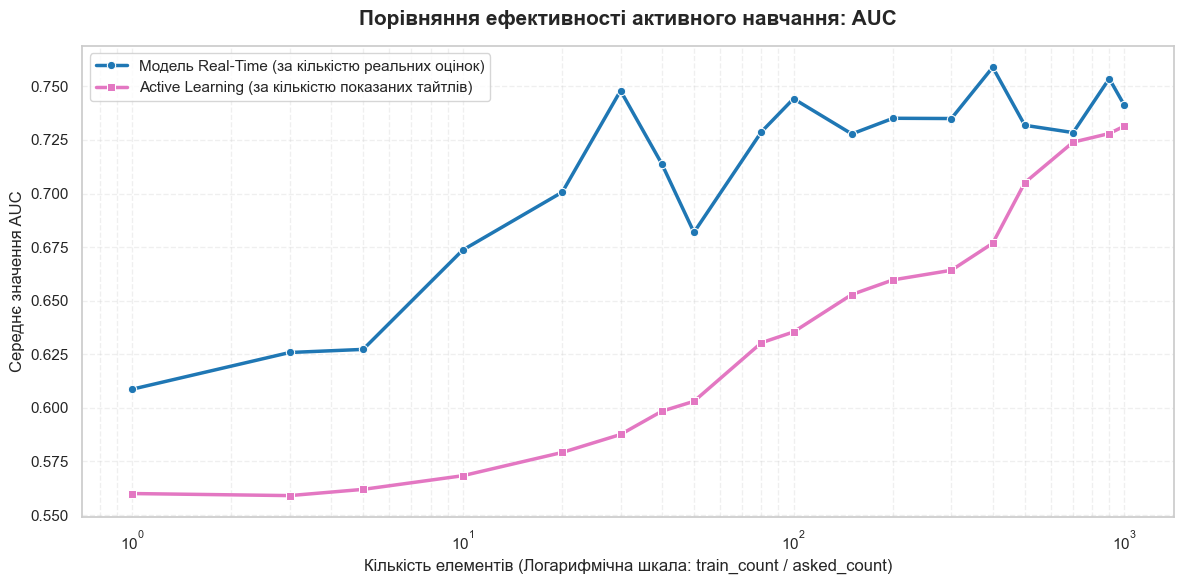

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування єдиного стилю візуалізації
sns.set_theme(style="whitegrid")

# Крок 1: Агрегуємо дані для першої лінії (Real-Time модель за реальними оцінками)
rt_trend = rt_metrics_df.groupby('train_count')[
    ['RT_Precision@10', 'RT_Recall@10', 'RT_MRR', 'RT_AUC']
].mean().reset_index()

# Крок 2: Агрегуємо дані для другої лінії (Active Learning за кількістю запитань)
al_trend = active_learning_metrics.groupby('asked_count')[
    ['Precision@10', 'Recall@10', 'MRR', 'AUC']
].mean().reset_index()

# Список метрик для циклу
metrics = ['Precision@10', 'Recall@10', 'MRR', 'AUC']

print("Генерація порівняльних графіків...")

# Крок 3: Цикл побудови та демонстрації окремого графіка для кожної метрики
for metric in metrics:
    # Створюємо полотно для поточного графіка
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Лінія 1: Real-Time модель (X = train_count, Y = RT_метрика)
    sns.lineplot(
        data=rt_trend,
        x='train_count',
        y=f'RT_{metric}',
        marker='o',
        linewidth=2.5,
        label='Модель Real-Time (за кількістю реальних оцінок)',
        color='#1f77b4',
        ax=ax
    )
    
    # Лінія 2: Active Learning модель (X = asked_count, Y = метрика)
    sns.lineplot(
        data=al_trend,
        x='asked_count',
        y=metric,
        marker='s',
        linewidth=2.5,
        label='Active Learning (за кількістю показаних тайтлів)',
        color='#e377c2',
        ax=ax
    )
    
    # Налаштування логарифмічної шкали та підписів українською мовою
    ax.set_xscale('log')
    ax.set_title(f'Порівняння ефективності активного навчання: {metric}', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Кількість елементів (Логарифмічна шкала: train_count / asked_count)', fontsize=12)
    ax.set_ylabel(f'Середнє значення {metric}', fontsize=12)
    
    # Налаштування сітки та легенди
    ax.grid(True, which="both", alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, loc='best')
    
    plt.tight_layout()
    
    # Демонструємо графік безпосередньо на екран (кожен у власному блоці виводу)
    plt.show()
    
    print("\n" + "="*80 + "\n")

Розрахунок середньої конверсії онбордингу...


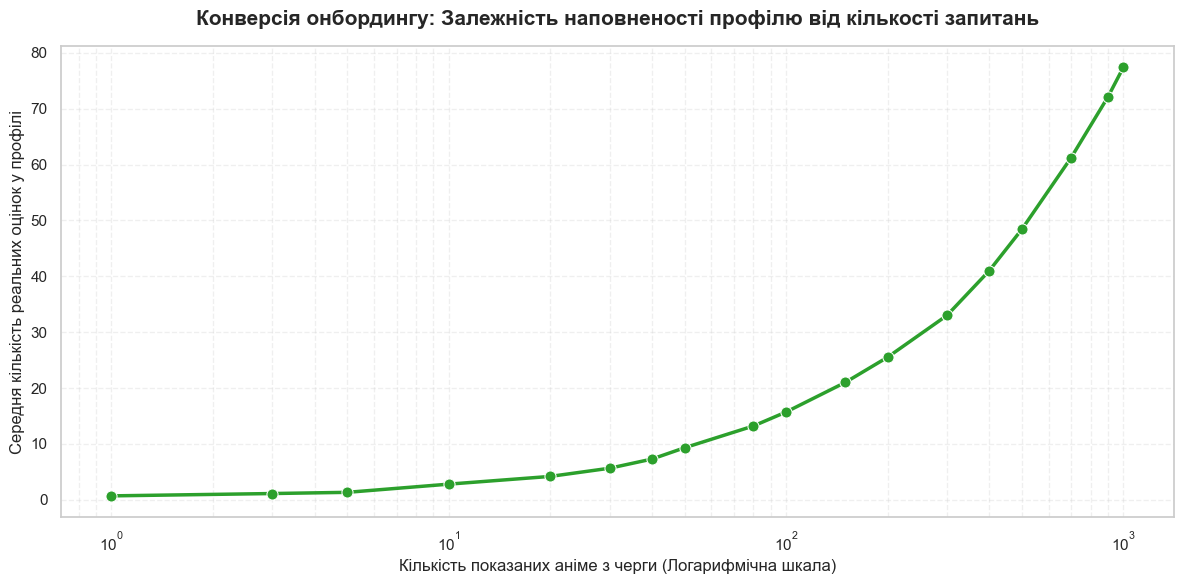


Точні значення конверсії (Показано питань -> Отримано оцінок в середньому):
 asked_count  profile_size
           1          0.69
           3          1.11
           5          1.33
          10          2.79
          20          4.18
          30          5.65
          40          7.28
          50          9.30
          80         13.21
         100         15.71
         150         21.03
         200         25.52
         300         33.01
         400         40.99
         500         48.42
         700         61.25
         900         72.13
        1000         77.43


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю візуалізації
sns.set_theme(style="whitegrid")

print("Розрахунок середньої конверсії онбордингу...")

# Групуємо дані: рахуємо середнє значення реальних оцінок (profile_size) для кожного кроку (asked_count)
conversion_trend = active_learning_metrics.groupby('asked_count')['profile_size'].mean().reset_index()

# Створюємо полотно для графіка
fig, ax = plt.subplots(figsize=(12, 6))

# Побудова лінійного графіка
sns.lineplot(
    data=conversion_trend,
    x='asked_count',
    y='profile_size',
    marker='o',
    linewidth=2.5,
    color='#2ca02c',  # насичений зелений колір
    markersize=8,
    ax=ax
)

# Налаштування логарифмічної шкали для осі X
ax.set_xscale('log')

# Підписи заголовка та осей українською мовою
ax.set_title('Конверсія онбордингу: Залежність наповненості профілю від кількості запитань', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Кількість показаних аніме з черги (Логарифмічна шкала)', fontsize=12)
ax.set_ylabel('Середня кількість реальних оцінок у профілі', fontsize=12)

# Налаштування детальної сітки для логарифмічної шкали
ax.grid(True, which="both", alpha=0.3, linestyle='--')

plt.tight_layout()

# Демонструємо графік у вашому блокноті
plt.show()

# Додатково виведемо коротку текстову таблицю для точних цифр
print("\nТочні значення конверсії (Показано питань -> Отримано оцінок в середньому):")
print(conversion_trend.round(2).to_string(index=False))